> # **MANTENIMIENTO PREDICTIVO TALADRADORA**
---

<a id='top'></a>
# **Tabla de Contenidos (Table of Contents)**
 - [**1. Introducción y descripción del problema (*Introduction*)**](#1)
    - [**1.1 Planteamiento del problema (*Problem Statement*)**](#1_1)
       - [**1.1.1 Descripción del dataset original**](#1_1_1)
       - [**1.1.2 Objetivo**](#1_1_2)
    - [**1.2 Obtención del Dataset (*Data Collection*)**](#1_2)
    - [**1.3 Validación y verificación de calidad (*Data Validation & Checks*)**](#1_3)
 - [**2. Análisis Exploratorio de Datos (*EDA*)**](#2)
    - [**2.1 Análisis estadístico y visualización (*Data Visualization*)**](#2_1)
       - [**2.1.1 Matriz de correlaciones**](#2_1_1)
       - [**2.1.2 Distribución de las variables numéricas**](#2_1_2)
       - [**2.1.3 Diagramas de caja y bigote (*Boxplot*)**](#2_1_3)
       - [**2.1.4 Distribución de las variables categóricas**](#2_1_4)
       - [**2.1.5 Distribución del fallo principal de la taladradora**](#2_1_5)
       - [**2.1.6 Distribución de modos de fallo**](#2_1_6)
    - [**2.2 Identificación de patrones e insights (*Uncovering Patterns*)**](#2_2)
       - [**2.2.1 Relación entre la potencia de corte y la velocidad de corte**](#2_2_1)
       - [**2.2.2 Relación entre la velocidad de avance y la velocidad de corte**](#2_2_2)
       - [**2.2.3 Relación entre la refrigeración y la velocidad de corte**](#2_2_3)
       - [**2.2.4 Relación entre material y modo de fallo**](#2_2_4)
       - [**2.2.5 Relación entre modo de fallo y refrigeración**](#2_2_5)
       - [**2.2.6 Relación entre refrigeración, modos de fallo y materiales**](#2_2_6)
       - [**2.2.7 Relación entre avance y modo de fallo**](#2_2_7)
       - [**2.2.8 Relación entre modo fallo y velocidad de avance**](#2_2_8)
       - [**2.2.9 Relación entre modo de fallo y potencia de corte**](#2_2_9)
       - [**2.2.10 Relación entre modo de fallo y velocidad de corte**](#2_2_10)
       - [**2.2.11 Relación entre modo de fallo y tiempo de proceso**](#2_2_11)
 - [**3. Preprocesamiento e ingeniería de características (*Data Preprocessing*)**](#3)
    - [**3.1 Selección de variables (*Feature Selection*)**](#3_1)
    - [**3.2 Codificación de las variables categóricas y separación de variables (*Encoding*)**](#3_2)
    - [**3.3 Separar X e y (*Train/Test Split*)**](#3_3)
    - [**3.4 Suprimir los casos con fallos simultáneos (*Cleaning*)**](#3_4)
    - [**3.5 Conversión de *y* a multiclase (*Multiclass Conversion*)**](#3_5)
    - [**3.6 División para entrenamiento y prueba (*Train/Test Split*)**](#3_6)
    - [**3.7 Normalización de los datos (*Scaling*)**](#3_7)
    - [**3.8 Tratamiento de datasets desbalanceados (*Handling Imbalance Dataset and Cleaning*)**](#3_8)
    - [**3.9 Codificación de las variables (LabelEncoder)**](#3_9)
 - [**4. Modelado y evaluación comparativa (*Modelling & Evaluation*)**](#4)
    - [**4.1 Entrenamiento de modelos y métricas (*Model Training*)**](#4_1)
    - [**4.2 Algoritmos implementados**](#4_2)
       - [**4.2.1 Regresión logística (*Logistic Regression*)**](#4_2_1)
       - [**4.2.2 Bosque aleatorio (*Random Forest*)**](#4_2_2)
       - [**4.2.3 XGBoost**](#4_2_3)
       - [**4.2.4 Red neuronal artificial (*Neural Network MLP*)**](#4_2_4)
    - [**4.3 Comparativa de las métricas de los mejores modelos (*Model Comparison*)**](#4_3)
    - [**4.4 Comprobación de sobreajuste**](#4_4)
 - [**5. Interpretabilidad y pruebas de los modelos (*XAI & Inference*)**](#5)
    - [**5.1 IA explicable: Análisis SHAP (*XAI - SHAP*)**](#5_1)
    - [**5.2 Inferencia para casos individuales (*Prediction for a Single Instance*)**](#5_2)
       - [**5.2.1 Inferencia sobre casos reales del test**](#5_2_1)
       - [**5.2.2 Inferencia sobre casos hipotéticos**](#5_2_2)
 - [**6. Diseño de la aplicación e interfaz (*Building the Application*)**](#6)

<a id='1'></a>
# **1. Introducción y descripción del problema (*Introduction*)**
---

<a id='1_1'></a>
## **1.1 Planteamiento del problema (*Problem Statement*)**

<a id='1_1_1'></a>
### **1.1.1 Descripción del dataset original**

Para este proyecto se emplea un conjunto de datos (*dataset*) sintético, enfocado en el análisis de los modos de fallo en procesos de mecanizado. Fue elaborado por Wallsberger, Knauer y Matzka (Universidad de Ciencias Aplicadas de Berlín) y está optimizado para propósitos de Inteligencia Artificial Explicable (XAI), con el fin de evaluar y comprender las causas que originan los fallos en este tipo de máquinas.

El conjunto se ha generado con un enfoque de aplicabilidad real en la industria y se basa en un proceso de taladrado simple, en el que se mecaniza el mismo tipo de agujero para tres materiales con una profundidad de 60 mm.

### **Características**

El *dataset* está compuesto por **20.000 puntos de datos** (filas), que incluyen 10 características (variables predictoras), una etiqueta binaria de fallo principal y cuatro etiquetas binarias para el tipo de fallo:

- **Variables predictoras:** identificador (ID), velocidad de corte ($v_c$), avance ($f$), velocidad del husillo ($n$), velocidad de avance ($v_f$), potencia consumida ($P_c$) y tiempo de proceso ($t$).
- **Variables de configuración:**
  - **Material:** acero C45K (P), fundición GJL-250 (K) y aleación de metal no ferroso AlSi (N).
  - **Refrigeración:** variable discreta entre 0 y 100 %, con saltos de 25 %.
  - **Tipo de broca** (según norma DIN 1836): N para acero C45K, H para fundición y W para aleación AlSi. Cada broca tiene 2 filos.

### **Modos de fallo**

La tasa de fallo principal (*main failure*) se sitúa aproximadamente en el **5,0 %** del total. Si esta etiqueta vale 1, se ha producido al menos uno de los cuatro modos de fallo secundarios, categorizados por expertos en mecanizado:

- **Filo recrecido** (*Build-up edge failure*, BEF, 215 casos): causado generalmente por bajas velocidades de corte e insuficiente refrigeración.
- **Virutas comprimidas** (*Compression chips failure*, CCF, 344 casos): tiene tres posibles causas (velocidad de avance demasiado alta, refrigeración insuficiente o broca incorrecta); deben darse al menos dos de ellas.
- **Desgaste de flanco** (*Flank wear failure*, FWF, 278 casos): se produce por una velocidad de avance demasiado elevada junto a una velocidad de corte demasiado baja.
- **Herramienta incorrecta** (*Wrong drill bit failure*, WDF, 300 casos): causada por el uso de una broca inadecuada para el material.

Para aumentar el realismo, los autores introdujeron anomalías controladas, como un incremento del 30 % en la velocidad de avance en muestras con refrigeración insuficiente, simulando las desviaciones típicas de una planta real.

### **Origen de los parámetros**

- Los parámetros base se obtuvieron con la herramienta *Walter GPS*, estableciendo condiciones óptimas para tres materiales: acero C45K (EN 1.0503), fundición GJL (EN GJL-250) y aleación de aluminio-silicio (EN AC-42000).
- Las variables velocidad de corte ($v_c$) y avance ($f$) se generaron mediante una distribución gaussiana multivariante, y el tiempo de proceso ($t$) mediante una univariante.
- El resto de parámetros se calcularon con las siguientes ecuaciones:

Velocidad del husillo, donde $D$ es el diámetro de la broca (12 mm):

$$n = \frac{v_c \cdot 1000}{D \cdot \pi} \quad \left[\frac{1}{min}\right]$$

Velocidad de avance:

$$v_f = f \cdot n \quad \left[\frac{mm}{min}\right]$$

Fuerza de taladrado (reproducida tal como la definen los autores del *dataset*, conservando las unidades de la fuente original):

$$F = f \cdot D \cdot \pi \cdot n \quad \left[\frac{mm}{min}\right]$$

Potencia de corte:

$$P_c = \frac{F \cdot v_c}{1000} \quad [kW]$$

### **Obtención**

El *dataset* se ha obtenido a través de **Kaggle**: https://www.kaggle.com/datasets/raphaelwallsberger/xai-drilling-dataset y forma parte de la publicación de la conferencia TransAI 2023:
R. Wallsberger, R. Knauer, S. Matzka; "Explainable Artificial Intelligence in Mechanical Engineering: A Synthetic Dataset for Comprehensive Failure Mode Analysis"
DOI: http://dx.doi.org/10.1109/TransAI60598.2023.00032

<a id='1_1_2'></a>
### **1.1.2 Objetivo**

El objetivo de este proyecto es comparar diferentes algoritmos de *Machine Learning* para predecir diferentes modos de fallos basados en los datos generados con un programa de simulación de una máquina de mecanizado (taladradora).

Al identificar el tipo de fallo antes de que se produzca (mantenimiento predictivo) es posible reducir el tiempo de la máquina en parado.

<a id='1_2'></a>
## **1.2 Obtención del Dataset (*Data Collection*)**

**Importación de datos, paquetes y librerías necesarias**

In [1]:
!pip install imbalanced-learn # SMOTETomek
!pip install --upgrade gradio  # gradio interfaz

In [2]:
# Importar librerías
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Gráficas visibles en "notebook"
%matplotlib inline
import seaborn as sns

# Analisis EDA
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


# Preprocesamiento
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
# SMOTE y SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Cuatro modelos a implementar
# --------------------------------------------------
# LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
# --------------------------------------------------
# RANDOM FOREST
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
# --------------------------------------------------
# XGBOOST
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
# --------------------------------------------------
# RED NEURONAL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
# --------------------------------------------------
# XAI - SHAP
import shap
import joblib
from sklearn.utils import resample
# --------------------------------------------------
# Visualización en interfaz
import gradio as gr

import warnings
warnings.filterwarnings('ignore')

**Importar el conjunto de datos (CSV Data) como Pandas DataFrame**

In [3]:
# Descarga del dataset desde Kaggle
path = kagglehub.dataset_download("raphaelwallsberger/xai-drilling-dataset")

# Cargar el dataset
taladradora_datos = pd.read_csv(path + "/XAI_Drilling_Dataset.csv")

print(f"Tamaño del DataFrame taladradora_datos: {taladradora_datos.shape}")

Using Colab cache for faster access to the 'xai-drilling-dataset' dataset.
Tamaño del DataFrame taladradora_datos: (20000, 15)


<a id='1_3'></a>
## **1.3 Validación y verificación de calidad (*Data Validation & Checks*)**

In [4]:
taladradora_datos.head(5)

,ID,Cutting speed vc [m/min],Spindle speed n [1/min],Feed f [mm/rev],Feed rate vf [mm/min],Power Pc [kW],Cooling [%],Material,Drill Bit Type,Process Time [sec],Main Failure,BEF,CCF,FWF,WDF
0,1,29.92,794,0.218,173,194.87,75,N,W,19.26,0,0,0,0,0
1,2,29.85,792,0.241,191,214.71,75,N,W,19.55,0,0,0,0,0
2,3,22.85,606,0.183,111,95.68,50,P,N,36.16,0,0,0,0,0
3,4,29.60,785,0.236,237,206.93,75,N,W,21.22,1,0,0,1,0
4,5,17.43,462,0.246,114,74.85,50,K,H,33.56,0,0,0,0,0


Cambio de nombre de las variables para eliminar espacios que puedan generar errores en el código más adelante y con su traducción correspondiente.

In [5]:
columnas_espanol = {
    'ID': 'id',
    'Cutting speed vc [m/min]': 'velocidad_corte',
    'Spindle speed n [1/min]': 'velocidad_husillo',
    'Feed f [mm/rev]': 'avance',
    'Feed rate vf [mm/min]': 'velocidad_avance',
    'Power Pc [kW]': 'potencia_corte',
    'Cooling [%]': 'refrigeracion',
    'Process Time [sec]': 'tiempo_proceso',
    # Fallo y tipos de fallos
    'Main Failure': 'fallo_principal',
    'BEF': 'fallo_filo_recrecido',
    'CCF': 'fallo_viruta_comprimida',
    'FWF': 'fallo_desgaste_flanco',
    'WDF': 'fallo_broca_incorrecta',
    # Variables categóricas
    'Material': 'material',
    'Drill Bit Type': 'tipo_broca'
}

taladradora_datos = taladradora_datos.rename(columns=columnas_espanol)

**Mostrar en pantalla valores del conjunto de datos**

In [6]:
taladradora_datos.head(5)

,id,velocidad_corte,velocidad_husillo,avance,velocidad_avance,potencia_corte,refrigeracion,material,tipo_broca,tiempo_proceso,fallo_principal,fallo_filo_recrecido,fallo_viruta_comprimida,fallo_desgaste_flanco,fallo_broca_incorrecta
0,1,29.92,794,0.218,173,194.87,75,N,W,19.26,0,0,0,0,0
1,2,29.85,792,0.241,191,214.71,75,N,W,19.55,0,0,0,0,0
2,3,22.85,606,0.183,111,95.68,50,P,N,36.16,0,0,0,0,0
3,4,29.60,785,0.236,237,206.93,75,N,W,21.22,1,0,0,1,0
4,5,17.43,462,0.246,114,74.85,50,K,H,33.56,0,0,0,0,0


In [7]:
taladradora_datos.tail(5)

,id,velocidad_corte,velocidad_husillo,avance,velocidad_avance,potencia_corte,refrigeracion,material,tipo_broca,tiempo_proceso,fallo_principal,fallo_filo_recrecido,fallo_viruta_comprimida,fallo_desgaste_flanco,fallo_broca_incorrecta
19995,19996,22.93,608,0.203,124,106.88,50,P,N,34.02,0,0,0,0,0
19996,19997,30.40,806,0.265,214,245.36,100,N,W,19.86,0,0,0,0,0
19997,19998,22.91,608,0.204,124,106.89,50,P,N,33.96,0,0,0,0,0
19998,19999,22.65,601,0.184,110,94.26,50,P,N,35.86,0,0,0,0,0
19999,20000,29.69,787,0.226,178,199.49,75,N,W,20.55,0,0,0,0,0


In [8]:
taladradora_datos.sample(5)

,id,velocidad_corte,velocidad_husillo,avance,velocidad_avance,potencia_corte,refrigeracion,material,tipo_broca,tiempo_proceso,fallo_principal,fallo_filo_recrecido,fallo_viruta_comprimida,fallo_desgaste_flanco,fallo_broca_incorrecta
11647,11648,22.67,601,0.207,124,106.40,50,P,N,34.40,0,0,0,0,0
19482,19483,29.93,794,0.241,191,215.64,75,N,H,20.29,1,0,0,0,1
13234,13235,22.49,597,0.177,105,89.31,50,P,N,35.16,0,0,0,0,0
7016,7017,22.29,591,0.159,94,79.21,25,P,N,36.32,0,0,0,0,0
17917,17918,29.68,787,0.213,168,187.80,75,N,W,19.40,0,0,0,0,0


**Columnas que presentan como mínimo un modo de fallo**

In [9]:
taladradora_datos[taladradora_datos.fallo_principal==1]

,id,velocidad_corte,velocidad_husillo,avance,velocidad_avance,potencia_corte,refrigeracion,material,tipo_broca,tiempo_proceso,fallo_principal,fallo_filo_recrecido,fallo_viruta_comprimida,fallo_desgaste_flanco,fallo_broca_incorrecta
3,4,29.60,785,0.236,237,206.93,75,N,W,21.22,1,0,0,1,0
90,91,21.80,578,0.127,94,60.25,0,P,N,35.22,1,1,0,0,0
102,103,22.46,596,0.151,117,75.90,25,P,W,34.32,1,0,1,0,1
109,110,29.50,783,0.216,216,188.00,75,N,W,20.73,1,0,0,1,0
114,115,22.00,583,0.140,82,67.68,0,P,N,33.88,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19923,19924,22.59,599,0.166,129,84.66,25,P,N,34.89,1,0,1,0,0
19959,19960,29.51,783,0.227,227,197.37,75,N,W,19.88,1,0,0,1,0
19967,19968,30.32,804,0.279,224,256.50,100,N,H,20.00,1,0,1,0,1
19971,19972,17.40,462,0.258,119,78.08,50,K,N,31.92,1,0,0,0,1


**Dimensión del conjunto de datos**

In [10]:
taladradora_datos.shape

(20000, 15)

Información del conjunto de datos. El *dataset* contiene tres tipos de variables: int64, float y object.

In [11]:
taladradora_datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       20000 non-null  int64  
 1   velocidad_corte          20000 non-null  float64
 2   velocidad_husillo        20000 non-null  int64  
 3   avance                   20000 non-null  float64
 4   velocidad_avance         20000 non-null  int64  
 5   potencia_corte           20000 non-null  float64
 6   refrigeracion            20000 non-null  int64  
 7   material                 20000 non-null  object 
 8   tipo_broca               20000 non-null  object 
 9   tiempo_proceso           20000 non-null  float64
 10  fallo_principal          20000 non-null  int64  
 11  fallo_filo_recrecido     20000 non-null  int64  
 12  fallo_viruta_comprimida  20000 non-null  int64  
 13  fallo_desgaste_flanco    20000 non-null  int64  
 14  fallo_broca_incorrecta

**Resumen estadístico de las variables numéricas (cuantitativas)**

In [12]:
taladradora_datos.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
id,20000.0,10000.500000,5773.647028,1.000,5000.750,10000.500,15000.250,20000.000
velocidad_corte,20000.0,23.322470,5.174178,16.330,17.590,22.610,29.780,31.070
velocidad_husillo,20000.0,618.644400,137.248701,433.000,467.000,600.000,790.000,824.000
avance,20000.0,0.224831,0.037563,0.108,0.193,0.233,0.254,0.321
velocidad_avance,20000.0,140.629850,41.470466,62.000,109.000,122.000,183.000,261.000
potencia_corte,20000.0,128.992781,65.403239,49.040,78.510,93.250,203.600,305.220
refrigeracion,20000.0,56.750000,23.941933,0.000,50.000,50.000,75.000,100.000
tiempo_proceso,20000.0,29.242184,6.866544,15.970,20.360,32.960,34.530,38.570
fallo_principal,20000.0,0.050050,0.218054,0.000,0.000,0.000,0.000,1.000
fallo_filo_recrecido,20000.0,0.010750,0.103126,0.000,0.000,0.000,0.000,1.000


Estadísticas descriptivas del dataset:
- count: número de observaciones
- mean: media aritmética  
- std: desviación estándar
- min/max: valores mínimo y máximo
- 25%, 50%, 75%: cuartiles

**Resumen estadístico de las variables categóricas (cualitativas)**

Existen tres tipos de materiales y tres tipos de broca en todo el conjunto de datos.

In [13]:
taladradora_datos.describe(include="object").T

,count,unique,top,freq
material,20000,3,P,6674
tipo_broca,20000,3,N,6688


Columnas del dataframe

In [14]:
taladradora_datos.columns

Index(['id', 'velocidad_corte', 'velocidad_husillo', 'avance',
       'velocidad_avance', 'potencia_corte', 'refrigeracion', 'material',
       'tipo_broca', 'tiempo_proceso', 'fallo_principal',
       'fallo_filo_recrecido', 'fallo_viruta_comprimida',
       'fallo_desgaste_flanco', 'fallo_broca_incorrecta'],
      dtype='object')

En el conjunto de datos no faltan valores.

In [15]:
taladradora_datos.isna().sum()

,0
id,0
velocidad_corte,0
velocidad_husillo,0
avance,0
velocidad_avance,0
potencia_corte,0
refrigeracion,0
material,0
tipo_broca,0
tiempo_proceso,0


Se comprueba que no hay datos de diferentes tipos para una misma variable.

No existen tipos mezclados entre sí. Los datos son consistentes.

In [16]:
for col in taladradora_datos.columns:
    print(f"{col}: {taladradora_datos[col].apply(type).nunique()} unico tipo de variable")

id: 1 unico tipo de variable
velocidad_corte: 1 unico tipo de variable
velocidad_husillo: 1 unico tipo de variable
avance: 1 unico tipo de variable
velocidad_avance: 1 unico tipo de variable
potencia_corte: 1 unico tipo de variable
refrigeracion: 1 unico tipo de variable
material: 1 unico tipo de variable
tipo_broca: 1 unico tipo de variable
tiempo_proceso: 1 unico tipo de variable
fallo_principal: 1 unico tipo de variable
fallo_filo_recrecido: 1 unico tipo de variable
fallo_viruta_comprimida: 1 unico tipo de variable
fallo_desgaste_flanco: 1 unico tipo de variable
fallo_broca_incorrecta: 1 unico tipo de variable


Se verifica que no existen columnas con valores constantes.

No hay ninguna variable con un único dato constante.

In [17]:
for col in taladradora_datos.select_dtypes(exclude=['object']):
    if taladradora_datos[col].nunique() == 1:
        print(f"La variable '{col}' repite un dato constantemente.")
    else:
        print(f"La variable '{col}' tiene {taladradora_datos[col].nunique()} datos diferentes.")

La variable 'id' tiene 20000 datos diferentes.
La variable 'velocidad_corte' tiene 573 datos diferentes.
La variable 'velocidad_husillo' tiene 173 datos diferentes.
La variable 'avance' tiene 204 datos diferentes.
La variable 'velocidad_avance' tiene 190 datos diferentes.
La variable 'potencia_corte' tiene 9458 datos diferentes.
La variable 'refrigeracion' tiene 5 datos diferentes.
La variable 'tiempo_proceso' tiene 1286 datos diferentes.
La variable 'fallo_principal' tiene 2 datos diferentes.
La variable 'fallo_filo_recrecido' tiene 2 datos diferentes.
La variable 'fallo_viruta_comprimida' tiene 2 datos diferentes.
La variable 'fallo_desgaste_flanco' tiene 2 datos diferentes.
La variable 'fallo_broca_incorrecta' tiene 2 datos diferentes.


Verificación de datos que se repiten para cada variable.

No existen valores duplicados.

In [18]:
taladradora_datos.nunique()

,0
id,20000
velocidad_corte,573
velocidad_husillo,173
avance,204
velocidad_avance,190
potencia_corte,9458
refrigeracion,5
material,3
tipo_broca,3
tiempo_proceso,1286


**Verificar la integridad de los datos**

Identificar inconsistencias en el conjunto de datos con fallos

1. Encontrar instancias donde fallo_principal es 1 pero ninguno de los tipos de fallos tiene 1.

2. Encontrar instancias donde fallo_principal es 0 pero al menos un tipo de fallo es 1.

3. Extraer los casos de inconsistencias y examinar su número.

In [19]:
# Definición de columnas con los tipos de fallo
tipos_fallo = ['fallo_filo_recrecido', 'fallo_viruta_comprimida', 'fallo_desgaste_flanco', 'fallo_broca_incorrecta']

# Filtración de fallo_principal 1 y tipos de fallo 0
filtro_fallo_sin_tipo = (taladradora_datos.fallo_principal == 1) & (taladradora_datos[tipos_fallo].sum(axis=1) == 0)

# Filtración de fallo_principal 0 y al menos un tipo de fallo 1
filtro_no_fallo_con_tipo = (taladradora_datos.fallo_principal == 0) & (taladradora_datos[tipos_fallo].sum(axis=1) > 0)

# Extracción de las filas con inconsistencias basada en las filtraciones
taladradora_datos_fallos_sin_tipo = taladradora_datos[filtro_fallo_sin_tipo]
# Instancias con fallo_principal 1 pero tipo de fallo desconocido
df_taladradora_no_fallo_con_tipo = taladradora_datos[filtro_no_fallo_con_tipo]
# Instancias con fallo_principal 0 pero existe algún tipo de fallo

# Mostrar en pantalla
num_fallos_sin_tipo = len(taladradora_datos_fallos_sin_tipo)
num_no_fallo_con_tipo = len(df_taladradora_no_fallo_con_tipo)

print(f"Numero de casos donde el fallo principal es 1 pero todos los tipos de fallo son 0: {num_fallos_sin_tipo}")
print(f"Numero de casos donde el fallo principal es 0 pero, al menos, un tipo de fallo es 1: {num_no_fallo_con_tipo}")

Numero de casos donde el fallo principal es 1 pero todos los tipos de fallo son 0: 0
Numero de casos donde el fallo principal es 0 pero, al menos, un tipo de fallo es 1: 0


**Verificar si el conjunto de datos es multietiqueta**

In [20]:
# VERIFICAR SI EL DATASET ES MULTILABEL
total_muestras = len(taladradora_datos)

# Contar cuántos fallos tiene cada fila
taladradora_datos['num_fallos'] = taladradora_datos[tipos_fallo].sum(axis=1)

# Casos con múltiples fallos
fallos_multiples = taladradora_datos[taladradora_datos['num_fallos'] > 1]
num_fallos_multiples = len(fallos_multiples)
porcentaje = (num_fallos_multiples/total_muestras)

# ANÁLISIS DE FALLOS MÚLTIPLES SIMULTÁNEOS
# Ver la distribución
print("Número de fallos simultáneos:")
distribucion_fallos = taladradora_datos['num_fallos'].value_counts().sort_index()
for n_fallos, cantidad in distribucion_fallos.items():
    porcentaje_grupo = (cantidad / total_muestras) * 100
    print(f"  {n_fallos} fallo(s): {cantidad:4d} casos ({porcentaje_grupo:.2f}%)")

# Casos sin ningún fallo
casos_sin_fallo = taladradora_datos[taladradora_datos['num_fallos'] == 0]
print(f"\nCasos sin fallo: {len(casos_sin_fallo)} ({len(casos_sin_fallo)/total_muestras*100:.2f}%)")

# Combinaciones de fallos múltiples
# Crear una representación de las combinaciones
fallos_multiples_copy = fallos_multiples[tipos_fallo].copy()
fallos_multiples_copy['combinacion'] = fallos_multiples_copy.apply(
    lambda row: ' + '.join([col.replace('fallo_', '')
                            for col in tipos_fallo
                            if row[col] == 1]),
    axis=1
)

combinaciones = fallos_multiples_copy['combinacion'].value_counts()
print(f"\nCombinaciones de fallos múltiples:")
for combo, cantidad in combinaciones.head(5).items():
    print(f"  {combo}: {cantidad} casos")

# Limpiar columna temporal
taladradora_datos.drop('num_fallos', axis=1, inplace=True)

Número de fallos simultáneos:
  0 fallo(s): 18999 casos (94.99%)
  1 fallo(s):  887 casos (4.44%)
  2 fallo(s):   92 casos (0.46%)
  3 fallo(s):   22 casos (0.11%)

Casos sin fallo: 18999 (94.99%)

Combinaciones de fallos múltiples:
  viruta_comprimida + broca_incorrecta: 92 casos
  viruta_comprimida + desgaste_flanco + broca_incorrecta: 9 casos
  filo_recrecido + viruta_comprimida + desgaste_flanco: 8 casos
  filo_recrecido + viruta_comprimida + broca_incorrecta: 5 casos


**Identificar columnas con carácter discreto y continuo**

In [21]:
# Selección de todas las columnas numéricas (incluyendo int64 y float64)
taladradora_datos_eda_numericos = taladradora_datos.select_dtypes(include=[np.number])

# Identificación de las columnas binarias (columnas que solo toman valores 0 y 1)
columnas_datos_eda_binarios = taladradora_datos_eda_numericos.columns[taladradora_datos_eda_numericos.nunique() == 2]

# Eliminar las columnas binarias
taladradora_datos_eda_numericos_no_binarios = taladradora_datos_eda_numericos.drop(columns=columnas_datos_eda_binarios.union(['id']))

# Definir un umbral para diferencias correctamente las variables discretas de las continuas
umbral = 20  # Ajuste según las características del conjunto de datos

# Identificar columnas numéricas de carácter discreto (excluyendo columnas binarias anteriormente eliminadas)
columnas_discretas = [col for col in taladradora_datos_eda_numericos_no_binarios.columns if taladradora_datos_eda_numericos_no_binarios[col].nunique() <= umbral]

# Identificar columnas numéricas de carácter continuo
columnas_continuas = [col for col in taladradora_datos_eda_numericos_no_binarios.columns if taladradora_datos_eda_numericos_no_binarios[col].nunique() > umbral]

print("Columnas numéricas de carácter discreto:", columnas_discretas)
print("Columnas numéricas de carácter continuo:", columnas_continuas)

Columnas numéricas de carácter discreto: ['refrigeracion']
Columnas numéricas de carácter continuo: ['velocidad_corte', 'velocidad_husillo', 'avance', 'velocidad_avance', 'potencia_corte', 'tiempo_proceso']


In [22]:
taladradora_datos.head()

,id,velocidad_corte,velocidad_husillo,avance,velocidad_avance,potencia_corte,refrigeracion,material,tipo_broca,tiempo_proceso,fallo_principal,fallo_filo_recrecido,fallo_viruta_comprimida,fallo_desgaste_flanco,fallo_broca_incorrecta
0,1,29.92,794,0.218,173,194.87,75,N,W,19.26,0,0,0,0,0
1,2,29.85,792,0.241,191,214.71,75,N,W,19.55,0,0,0,0,0
2,3,22.85,606,0.183,111,95.68,50,P,N,36.16,0,0,0,0,0
3,4,29.60,785,0.236,237,206.93,75,N,W,21.22,1,0,0,1,0
4,5,17.43,462,0.246,114,74.85,50,K,H,33.56,0,0,0,0,0


**Verificación de las variables categóricas**

In [23]:
for col in taladradora_datos.select_dtypes(include='object'):
  print(f"Número de valores únicos en la columna '{col}': {taladradora_datos[col].nunique()}")
  print(f"Categorías en la columna '{col}': {taladradora_datos[col].unique()} \n")


print(f"Número de valores únicos en la columna 'refrigeracion': {taladradora_datos['refrigeracion'].nunique()}")
print(f"Categorías en la columna 'refrigeracion': {sorted(taladradora_datos['refrigeracion'].unique())} \n")

Número de valores únicos en la columna 'material': 3
Categorías en la columna 'material': ['N' 'P' 'K'] 

Número de valores únicos en la columna 'tipo_broca': 3
Categorías en la columna 'tipo_broca': ['W' 'N' 'H'] 

Número de valores únicos en la columna 'refrigeracion': 5
Categorías en la columna 'refrigeracion': [np.int64(0), np.int64(25), np.int64(50), np.int64(75), np.int64(100)] 



<a id='2'></a>
# **2. Análisis Exploratorio de Datos (*EDA*)**
---

<a id='2_1'></a>
## **2.1 Análisis estadístico y visualización (*Data Visualization*)**

<a id='2_1_1'></a>
### **2.1.1 Matriz de correlaciones**

Para analizar la dependencia de las variables numéricas se calculan correlaciones. Los valores obtenidos se representan mediante un mapa de calor. No se representan las variables con información binaria puesto que no pueden seguir una relación directa ni inversamente proporcional.

**Matriz de correlaciones para variables numéricas continuas (excluyendo variables binarias)**

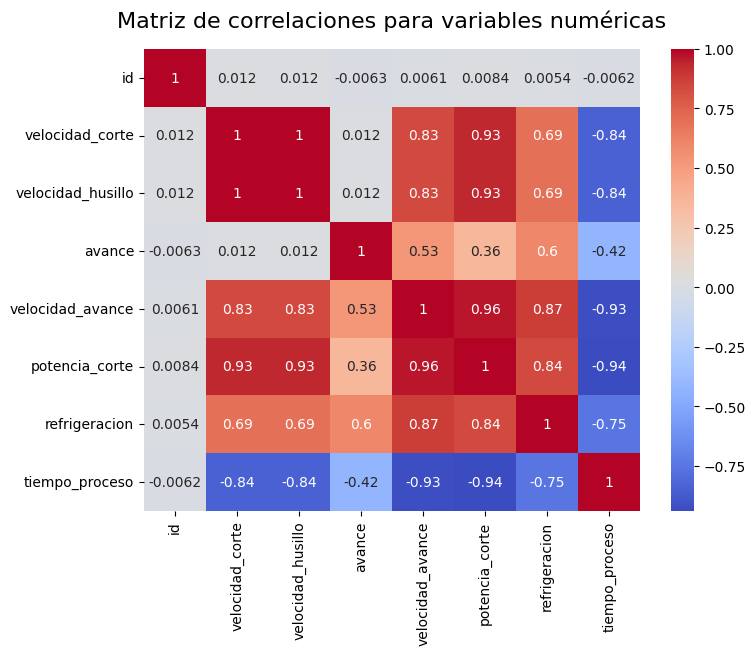

In [24]:
# Matriz de correlaciones para variables numéricas continuas (excluyendo variables binarias)

# Selección de todas las columnas que tienen variables numéricas (int64 y float64)
taladradora_datos_numericos = taladradora_datos.select_dtypes(include=[np.number])

# Identificación de las columnas con datos binarios (columnas con ceros y unos únicamente)
columnas_datos_binarios = taladradora_datos_numericos.columns[taladradora_datos_numericos.nunique() == 2]

# Eliminar las columnas binarias de la matriz de correlaciones
taladradora_datos_numericos_no_binarios = taladradora_datos_numericos.drop(columns=columnas_datos_binarios)

# Matriz de correlaciones para variables numéricas (excluyendo binarias)
plt.figure(figsize=(8,6))
sns.heatmap(taladradora_datos_numericos_no_binarios.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlaciones para variables numéricas",
          fontsize=16,
          pad=16)
plt.show()

**Análisis de Correlaciones entre Variables del Proceso**

Casos de multicolinealidad muy elevada:

**1. velocidad_husillo y velocidad_corte (r = 1.00)**
   - Correlación perfecta debido a su relación matemática directa
   - Medida: eliminar velocidad_husillo (redundante)
   
**2. velocidad_avance y potencia_corte (r = 0.96)**
   - Correlación casi perfecta
   - Medida: eliminar velocidad_avance y mantener potencia_corte (variable más informativa del estado del proceso)

**Correlaciones relevantes en el conjunto final**

Tras la eliminación de variables redundantes, se identifican las siguientes relaciones entre variables predictoras:

**Correlaciones positivas altas:**
- velocidad_corte y potencia_corte (r = 0.93): A mayor velocidad de corte,
  mayor consumo de potencia. Aunque es alta, se mantiene para
  representar aspectos complementarios del proceso (parámetro de entrada vs
  señal medida).
  
- potencia_corte y refrigeracion (r = 0.84): Mayor potencia genera más calor,
  lo que requiere mayor capacidad de refrigeración.

**Correlaciones negativas altas:**
- velocidad_corte y tiempo_proceso (r = -0.84)
- potencia_corte y tiempo_proceso (r = -0.94)
- refrigeracion y tiempo_proceso (r = -0.75)

Estas correlaciones son coherentes con el dataset, pues a mayores velocidades y potencias, los tiempos de mecanizado disminuyen.

**Correlaciones moderadas/bajas:**
- avance con otras variables (r = 0.36 - 0.60): El parámetro de avance aporta
  información independiente y complementaria a las demás
  variables.

**Resumen de acciones**

Se va a suprimir la variable velocidad del husillo debido a la correlación positiva perfecta con la variable velocidad de corte. Esto se debe a que la velocidad del husillo se calcula a partir de la velocidad de corte vc, donde
*vc = π × D × n* y D es el diámetro de la broca.

También se suprime la variable identificador puesto que no presenta relación ninguna con el resto de variables y tampoco información predictiva. Así como la velocidad de avance (para la matriz de correlaciones), pues tiene una correlación muy elevada con la potencia de corte y aporta información redundante que puede generar inestabilidad en los modelos.

**Matriz de correlaciones para variables numéricas continuas excluyendo variables binarias, la velocidad del husillo, la velocidad del avance, la refrigeración y el identificador**

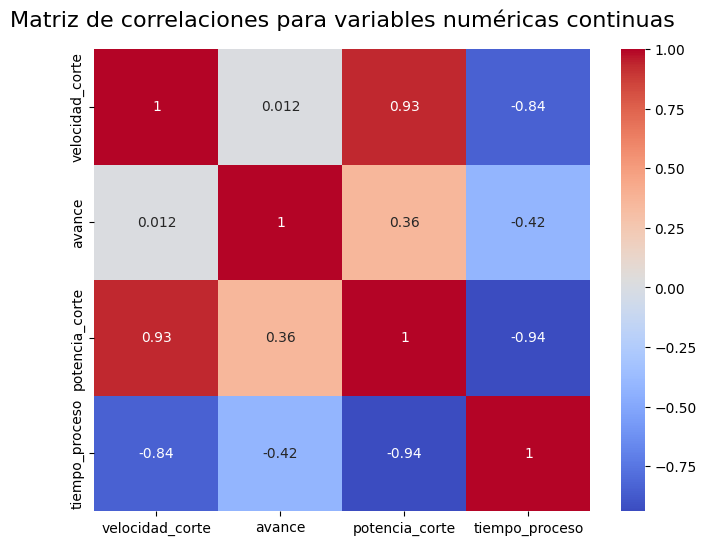

In [25]:
# Matriz de correlaciones para variables numéricas continuas
columnas_a_eliminar = ['id','velocidad_husillo','velocidad_avance','refrigeracion']
taladradora_datos_numericos_no_binarios = taladradora_datos_numericos_no_binarios.drop(columns=columnas_a_eliminar)

plt.figure(figsize=(8,6))
sns.heatmap(taladradora_datos_numericos_no_binarios.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlaciones para variables numéricas continuas",
          fontsize=16,
          pad=16)
plt.show()

Se elimina la velocidad del husillo, pero se mantiene la velocidad de avance, pues aporta información relevante en ciertos modos de fallo (se verá más adelante). El identificador también se suprime, pues es irrelevante para la detección de tipos de fallos. Por otro lado, la refrigeración, a pesar de tener valores numéricos, se categoriza como variable categórica y tampoco se incluye en la matriz final.

<a id='2_1_2'></a>
### **2.1.2 Distribución de las variables numéricas**

Distribución de las variables numéricas (posibles predictoras del fallo)

- Velocidad de corte: Presenta una distribución trimodal. Las velocidades de corte más comunes son las de 17, 22 y 30 m/min aproximadamente. Las tres distribuciones que se visualizan en la gráfica se corresponden con los tres tipos de materiales.

- Avance, velocidad del avance y potencia de corte: Presentan distribuciones bimodales, con valores de máxima frecuencia muy localizados. Se tomarán esos valores para las predicciones.

- Tiempo: Dos rangos de tiempo bastante diferenciados.

La refrigeración tiene valores numéricos pero con carácter discreto.

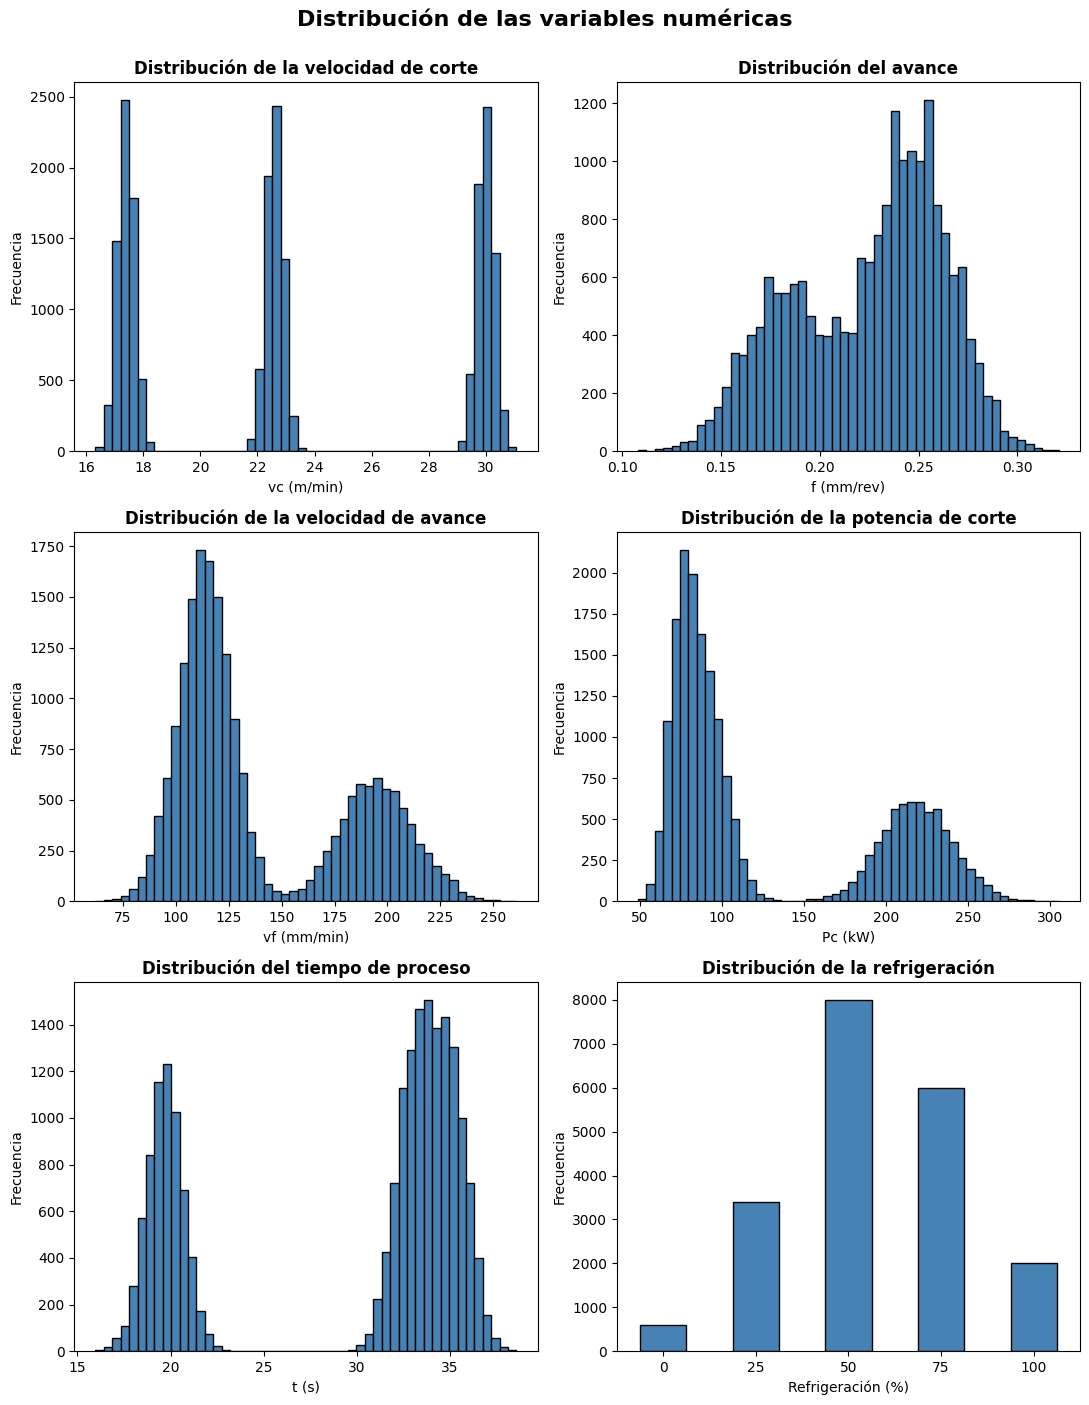

In [26]:
# Distribución de las variables numéricas
plt.figure(figsize=(11, 14))

plt.subplot(3, 2, 1)
plt.hist(taladradora_datos['velocidad_corte'], bins=50, color='steelblue', edgecolor='black')
plt.title("Distribución de la velocidad de corte", fontweight='bold')
plt.xlabel("vc (m/min)")
plt.ylabel("Frecuencia")

plt.subplot(3, 2, 2)
plt.hist(taladradora_datos['avance'], bins=50, color='steelblue', edgecolor='black')
plt.title("Distribución del avance", fontweight='bold')
plt.xlabel("f (mm/rev)")
plt.ylabel("Frecuencia")

plt.subplot(3, 2, 3)
plt.hist(taladradora_datos['velocidad_avance'], bins=50, color='steelblue', edgecolor='black')
plt.title("Distribución de la velocidad de avance",fontweight='bold')
plt.xlabel("vf (mm/min)")
plt.ylabel("Frecuencia")

plt.subplot(3, 2, 4)
plt.hist(taladradora_datos['potencia_corte'], bins=50, color='steelblue', edgecolor='black')
plt.title("Distribución de la potencia de corte", fontweight='bold')
plt.xlabel("Pc (kW)")
plt.ylabel("Frecuencia")

plt.subplot(3, 2, 5)
plt.hist(taladradora_datos['tiempo_proceso'], bins=50, color='steelblue', edgecolor='black')
plt.title("Distribución del tiempo de proceso", fontweight='bold')
plt.xlabel("t (s)")
plt.ylabel("Frecuencia")

plt.subplot(3, 2, 6)
taladradora_datos['refrigeracion'].value_counts().reindex([0, 25, 50, 75, 100]).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Distribución de la refrigeración", fontweight='bold')
plt.xlabel("Refrigeración (%)")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)

plt.suptitle('Distribución de las variables numéricas', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

<a id='2_1_3'></a>
### **2.1.3 Diagramas de caja y bigote (*Boxplot*)**

Detección de valores fuera de rango (*outliers*), mediante el uso de diagramas de caja y bigote (*boxplot*).

Los diagramas muestran rangos muy amplios pero sin *outliers* visibles. Esto tiene sentido pues el *dataset* ha sido generado de forma sintética mediante distribuciones gaussianas.

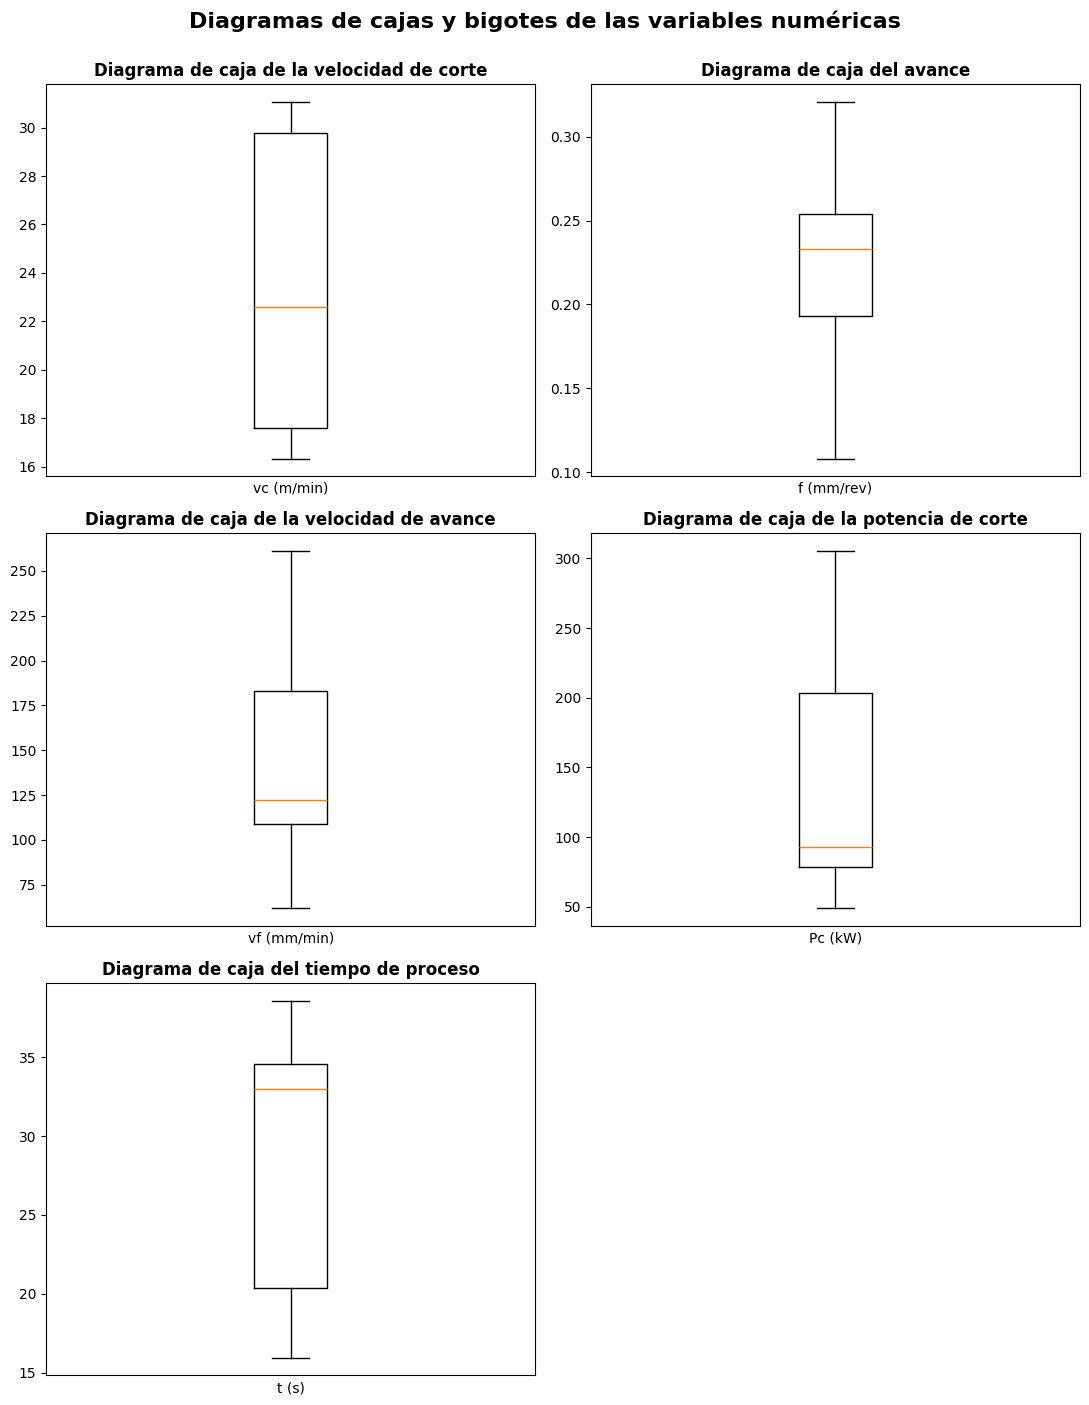

In [27]:
# Diagrama de cajas y bigotes (variables numéricas)
plt.figure(figsize=(11, 14))

plt.subplot(3, 2, 1)
plt.boxplot(taladradora_datos['velocidad_corte'])
plt.title("Diagrama de caja de la velocidad de corte", fontweight='bold')
plt.xlabel("vc (m/min)")
plt.xticks([])

plt.subplot(3, 2, 2)
plt.boxplot(taladradora_datos['avance'])
plt.title("Diagrama de caja del avance", fontweight='bold')
plt.xlabel("f (mm/rev)")
plt.xticks([])

plt.subplot(3, 2, 3)
plt.boxplot(taladradora_datos['velocidad_avance'])
plt.title("Diagrama de caja de la velocidad de avance", fontweight='bold')
plt.xlabel("vf (mm/min)")
plt.xticks([])

plt.subplot(3, 2, 4)
plt.boxplot(taladradora_datos['potencia_corte'])
plt.title("Diagrama de caja de la potencia de corte", fontweight='bold')
plt.xlabel("Pc (kW)")
plt.xticks([])

plt.subplot(3, 2, 5)
plt.boxplot(taladradora_datos['tiempo_proceso'])
plt.title("Diagrama de caja del tiempo de proceso",fontweight='bold')
plt.xlabel("t (s)")
plt.xticks([])

plt.suptitle('Diagramas de cajas y bigotes de las variables numéricas', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

<a id='2_1_4'></a>
### **2.1.4 Distribución de las variables categóricas**

Tanto los materiales como los tipos de brocas presentan una distribución equilibrada, con una distribución similar para cada tipo.

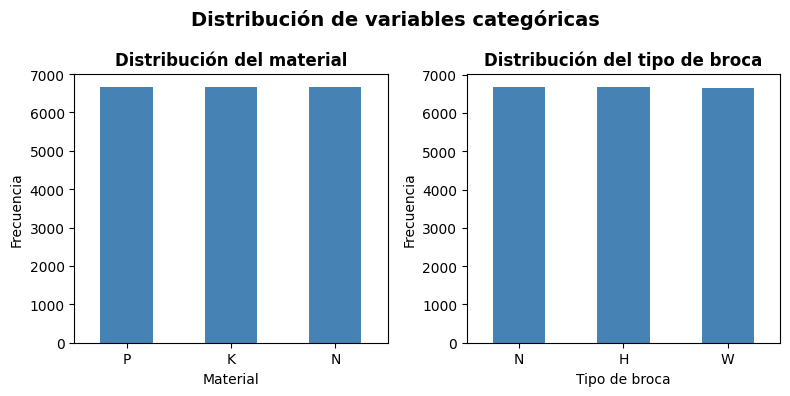

In [28]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
taladradora_datos['material'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribución del material', fontsize=12, fontweight='bold')
plt.xlabel('Material')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
taladradora_datos['tipo_broca'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribución del tipo de broca', fontsize=12, fontweight='bold')
plt.xlabel('Tipo de broca')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

plt.suptitle('Distribución de variables categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='2_1_5'></a>
### **2.1.5 Distribución del fallo principal de la taladradora**

Los fallos de la máquina son muy poco frecuentes (5%). Existe un alto desequilibrio de clases.

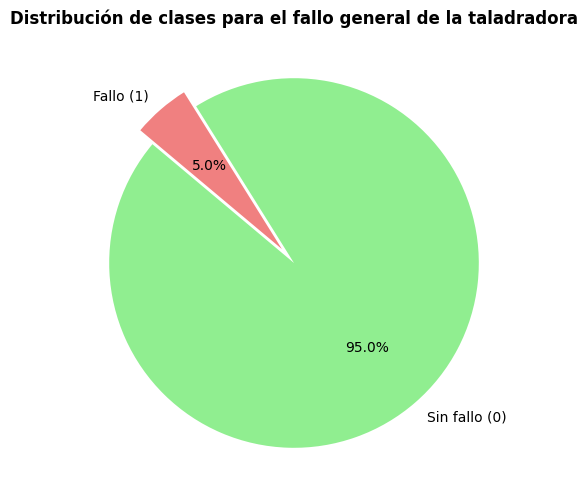

In [29]:
# Calcular distribución de clases para el fallo de la máquina taladradora
distribucion_clases = taladradora_datos['fallo_principal'].value_counts(normalize=True).sort_index()*100

# Etiquetas
etiquetas = ['Sin fallo (0)', 'Fallo (1)']
colores = ['lightgreen', 'lightcoral']

# Gráfico de sectores
plt.figure(figsize=(6,6))
plt.pie(distribucion_clases, labels=etiquetas, autopct='%1.1f%%', colors=colores, startangle=140, explode=[0, 0.1])
plt.title("Distribución de clases para el fallo general de la taladradora", fontweight='bold')
plt.show()

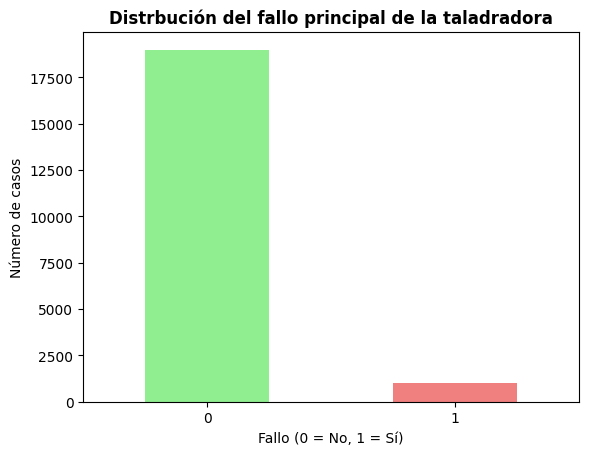

In [30]:
taladradora_datos['fallo_principal'].value_counts().plot(kind='bar', color=['lightgreen', 'lightcoral'])
plt.title("Distrbución del fallo principal de la taladradora", fontweight='bold')
plt.xlabel("Fallo (0 = No, 1 = Sí)")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.show()

<a id='2_1_6'></a>
### **2.1.6 Distribución de modos de fallo**

El diagrama de sectores muestra la distribución de cada modo de fallo entre los 1137 casos que presentaron al menos un fallo (5% del dataset total).

Los fallos se distribuyen:
- Viruta comprimida: 30.26% (344 casos)
- Broca incorrecta: 26.39% (300 casos)  
- Desgaste de flanco: 24.45% (277 casos)
- Filo recrecido: 18.91% (215 casos)

**Análisis de balance entre los modos de fallo:**

La distribución entre los modos de fallo es relativamente
equilibrada (variaciones de ±12% respecto a distribución uniforme). Esta distribución contrasta con el desbalance entre casos con fallo (5%) y sin fallo (95%) del dataset completo.

**Consideraciones para el modelado:**

1. **Desbalance principal (fallo vs no fallo):** se aplicarán técnicas de balanceo de datos en el preprocesamiento de los datos.

2. **Balance entre tipos de fallo:** se incluirán técnicas de balanceo a pesar de la distribución relativamente uniforme.

Los diferentes tipos de fallos tienen una proporción similar. Además, existen un total de 1137, de los cuales 1001 son fallos únicos que no presentan simultaneidad con otros tipos de fallos.


Número total de fallos: 1137
Número de instancias con fallo único o múltiplo: 1001

Distribución de los tipos de fallo entre todos los tipos de fallo (%):
fallo_filo_recrecido     -->  215 (18.91%)
fallo_viruta_comprimida  -->  344 (30.26%)
fallo_desgaste_flanco    -->  278 (24.45%)
fallo_broca_incorrecta   -->  300 (26.39%)




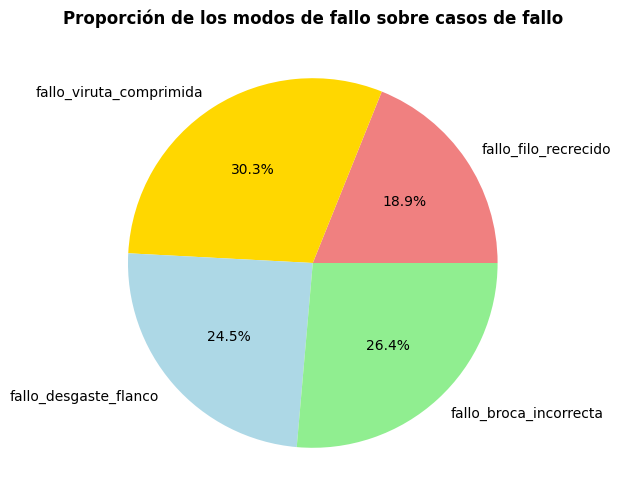

In [31]:
# Cálculo de los porcentajes de modo de fallo cuando fallo_maquina == 1
instancias_fallo = taladradora_datos[taladradora_datos['fallo_principal'] == 1]
distribucion_fallos = instancias_fallo[['fallo_filo_recrecido', 'fallo_viruta_comprimida', 'fallo_desgaste_flanco', 'fallo_broca_incorrecta']].sum()
total_fallos = distribucion_fallos.sum()
distribucion_fallos_porcentaje = (distribucion_fallos / total_fallos) * 100

# Mostrar en pantalla valores
print(f"Número total de fallos: {total_fallos}")
print(f"Número de instancias con fallo único o múltiplo: {len(instancias_fallo)}")
print("\nDistribución de los tipos de fallo entre todos los tipos de fallo (%):")
for t_fallo, cant in distribucion_fallos.items():
  porcent = (cant/total_fallos)*100
  print(f"{t_fallo:25s}--> {cant:4d} ({porcent:5.2f}%)")

print("\n")
plt.figure(figsize=(6,6))
plt.pie(distribucion_fallos, labels=distribucion_fallos.index, autopct='%1.1f%%', colors=['lightcoral', 'gold', 'lightblue', 'lightgreen', 'violet'])
plt.title("Proporción de los modos de fallo sobre casos de fallo", fontweight='bold')
plt.show()

<a id='2_2'></a>
## **2.2 Identificación de patrones e insights (*Uncovering Patterns*)**

Para no modificar el dataset en caso de que fuera necesario, se crea una copia.

In [32]:
taladradora_datos_eda = taladradora_datos.copy()

<a id='2_2_1'></a>
### **2.2.1 Relación entre la potencia de corte y la velocidad de corte**


1. Se diferencian 3 grupos, correspondientes a los 3 materiales:
- K -> velocidades bajas (17-19 m/min) y potencias bajas (50-110 kW) -> GJL-250
- P  -> velocidades medias (21-24 m/min) y potencias medias (50-140 kW) -> C45K
- N -> velocidades altas (29-31 m/min) y potencias altas (150-300 kW) -> AlSi

2. Se observa que al aumentar la velocidad de corte, la potencia de corte también aumenta (Pc = F·vc/1000). Se confirma la correlación positiva.

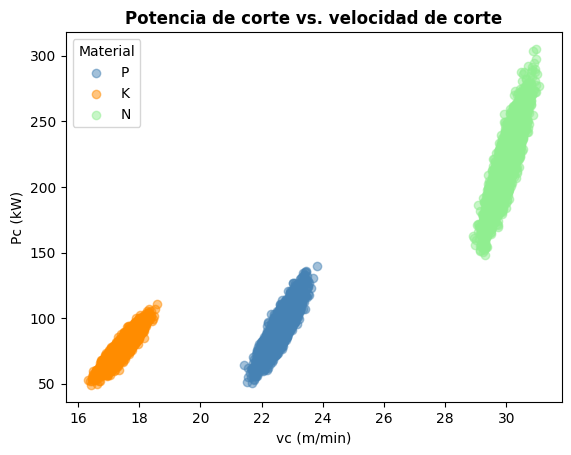

In [33]:
colores = {'P': 'steelblue', 'K': 'darkorange', 'N': 'lightgreen'}

for material, color in colores.items():
    subset = taladradora_datos_eda[taladradora_datos_eda['material'] == material]
    plt.scatter(subset['velocidad_corte'], subset['potencia_corte'],
                alpha=0.5, color=color, label=material)

plt.title("Potencia de corte vs. velocidad de corte", fontweight='bold')
plt.xlabel("vc (m/min)")
plt.ylabel("Pc (kW)")
plt.legend(title='Material')
plt.show()

<a id='2_2_2'></a>
### **2.2.2 Relación entre la velocidad de avance y la velocidad de corte**

1. Se diferencian 3 grupos, correspondientes a los 3 materiales:
- K -> velocidades de corte bajas (17-19 m/min) y velocidades de avance bajas (75-160 mm/min) -> GJL-250
- P -> velocidades de corte medias (21-24 m/min) y velocidades de avance medias (100-160 mm/min) -> C45K
- N -> velocidades de corte altas (29-31 m/min) y velocidades de avance altas (140-250 mm/min) -> AlSi

2. Se observa que al aumentar la velocidad de corte, la velocidad de avance también aumenta (vf = f·n). Se confirma la correlación positiva.

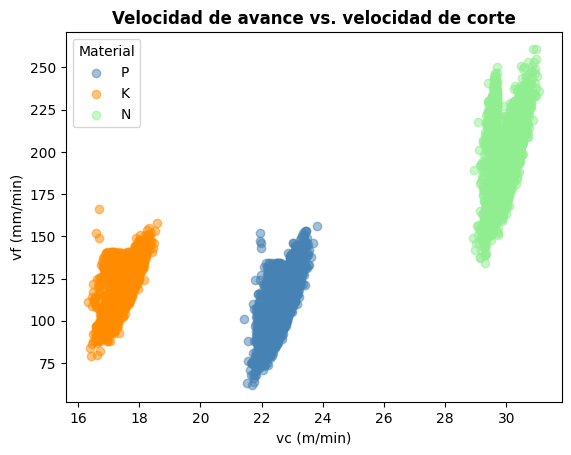

In [34]:
colores = {'P': 'steelblue', 'K': 'darkorange', 'N': 'lightgreen'}

for material, color in colores.items():
    subset = taladradora_datos_eda[taladradora_datos_eda['material'] == material]
    plt.scatter(subset['velocidad_corte'], subset['velocidad_avance'],
                alpha=0.5, color=color, label=material)

plt.title("Velocidad de avance vs. velocidad de corte", fontweight='bold')
plt.xlabel("vc (m/min)")
plt.ylabel("vf (mm/min)")
plt.legend(title='Material')
plt.show()

<a id='2_2_3'></a>
### **2.2.3 Relación entre la refrigeración y la velocidad de corte**

Como la refrigeración es una variable categórica, se representa su relación con la velocidad de corte mediante diagramas de cajas y bigotes. Además, diferenciaremos entre cada tipo de material para que no aparezcan falsos *outliers*.

Se observa que el nivel de refrigeración depende del material empleado:
- El acero C45K (P) trabaja a velocidades menores que el resto de materiales y con un nivel de refrigeración bajo-medio.
- La fundición GJL (K) trabaja a mayores velocidades de corte y con valores similares de refrigeración que el acero.
- La aleación AlSi (N) trabaja a velocidades mucho más elevadas y por tanto, está sometido a una refrigeración muy alta.

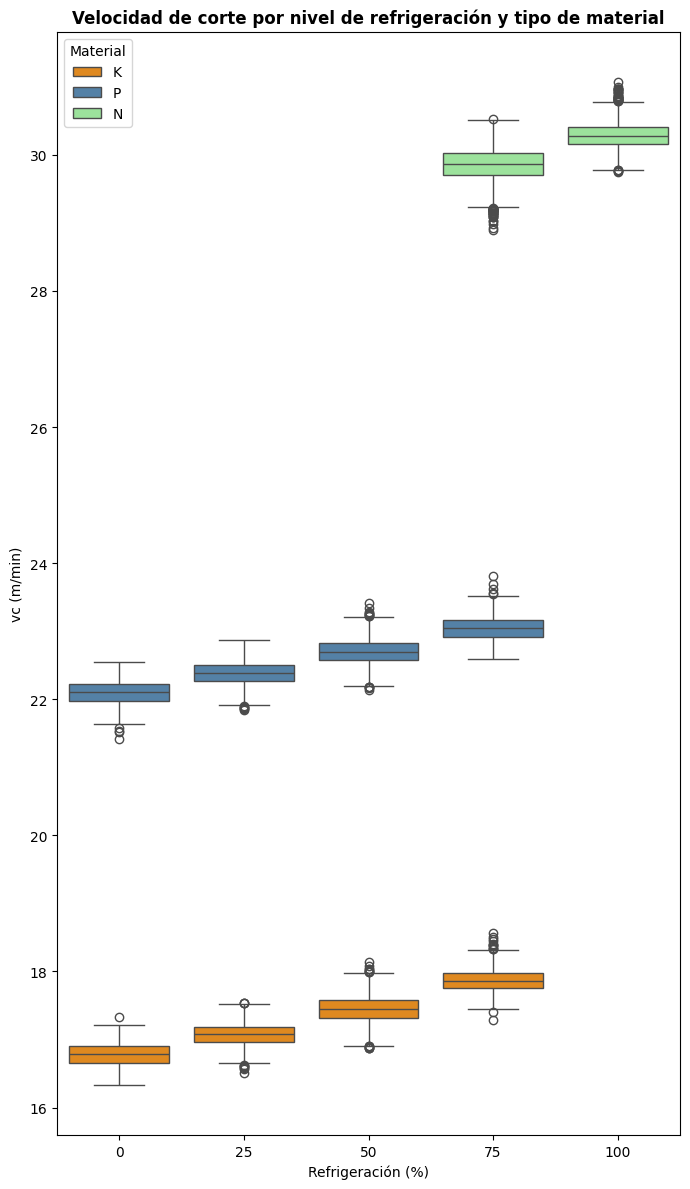

In [35]:
plt.figure(figsize=(7, 12))

sns.boxplot(data=taladradora_datos_eda,
            x='refrigeracion',
            y='velocidad_corte',
            hue='material',
            palette={'P': 'steelblue', 'K': 'darkorange', 'N': 'lightgreen'},
            dodge=False) # Para superponer sobre el eje x

plt.title("Velocidad de corte por nivel de refrigeración y tipo de material", fontsize=12, fontweight='bold')
plt.xlabel("Refrigeración (%)")
plt.ylabel("vc (m/min)")
plt.legend(title='Material')
plt.tight_layout()
plt.show()

<a id='2_2_4'></a>
### **2.2.4 Relación entre material y modo de fallo**

Para tener una vista más simple de la relación entre tipos de fallo y material, se va a realizar una representación gráfica de dicha relación.

- Filo recrecido: predomina en el material P (tiende de a acumularse en el filo de la herramienta).

- Viruta comprimida: número similar en P y K; y bajo en N.

- Desgaste flanco: prácticamente todos los casos son de N.

- Broca incorrecta: distribuido entre los 3 materiales, no depende del tipo de material.

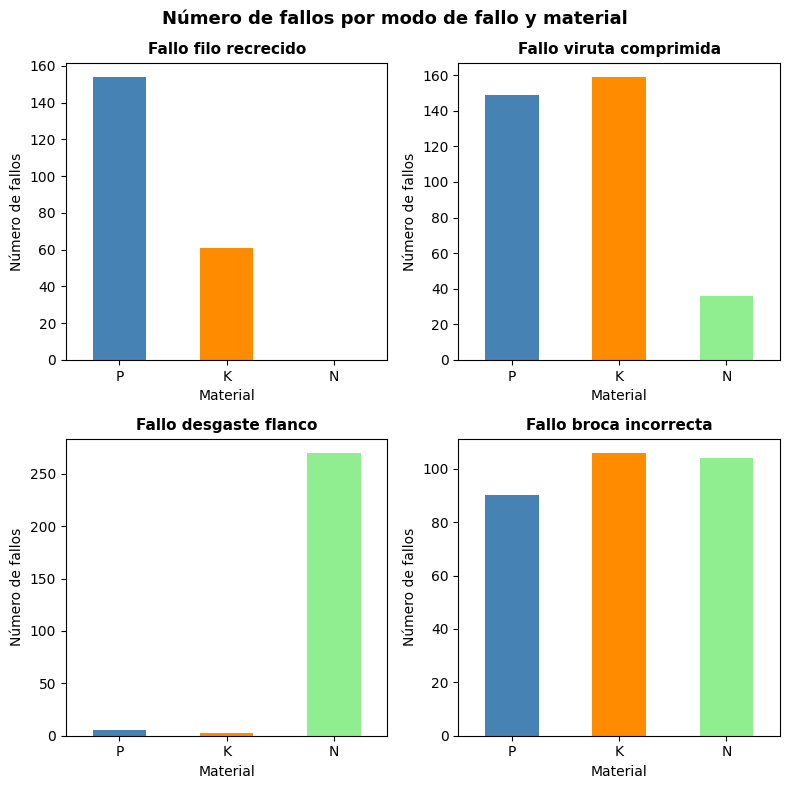

In [36]:
materiales = ['P', 'K', 'N']

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
taladradora_datos_eda[taladradora_datos_eda['fallo_filo_recrecido'] == 1]['material'].value_counts().reindex(materiales, fill_value=0).plot(kind='bar', color=['steelblue', 'darkorange', 'lightgreen'])
plt.title('Fallo filo recrecido', fontsize=11, fontweight='bold')
plt.xlabel("Material")
plt.ylabel("Número de fallos")
plt.xticks(rotation=0)

plt.subplot(2, 2, 2)
taladradora_datos_eda[taladradora_datos_eda['fallo_viruta_comprimida'] == 1]['material'].value_counts().reindex(materiales, fill_value=0).plot(kind='bar', color=['steelblue', 'darkorange', 'lightgreen'])
plt.title('Fallo viruta comprimida', fontsize=11, fontweight='bold')
plt.xlabel("Material")
plt.ylabel("Número de fallos")
plt.xticks(rotation=0)

plt.subplot(2, 2, 3)
taladradora_datos_eda[taladradora_datos_eda['fallo_desgaste_flanco'] == 1]['material'].value_counts().reindex(materiales, fill_value=0).plot(kind='bar', color=['steelblue', 'darkorange', 'lightgreen'])
plt.title('Fallo desgaste flanco', fontsize=11, fontweight='bold')
plt.xlabel("Material")
plt.ylabel("Número de fallos")
plt.xticks(rotation=0)

plt.subplot(2, 2, 4)
taladradora_datos_eda[taladradora_datos_eda['fallo_broca_incorrecta'] == 1]['material'].value_counts().reindex(materiales, fill_value=0).plot(kind='bar', color=['steelblue', 'darkorange', 'lightgreen'])
plt.title('Fallo broca incorrecta', fontsize=11, fontweight='bold')
plt.xlabel("Material")
plt.ylabel("Número de fallos")
plt.xticks(rotation=0)

plt.suptitle('Número de fallos por modo de fallo y material', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='2_2_5'></a>
### **2.2.5 Relación entre modo de fallo y refrigeración**

- Fallo filo recrecido: se produce mayoritariamente cuando la refrigeración es nula (0%), y en algunas ocasiones cuando es baja (25%).
- Fallo viruta comprimida: ocurre principalmente con un nivel de refrigeración del 25%.
- Fallo desgaste flanco: se da prácticamente con refrigeración al 75%. Para saber si se da con un material concreto, se va a repetir la gráfica incluyendo el tipo de material con la paleta de colores previamente empleada.
- Fallo broca incorrecta: distribuido entre todos los niveles. Este tipo de fallo no depende de la refrigeración.

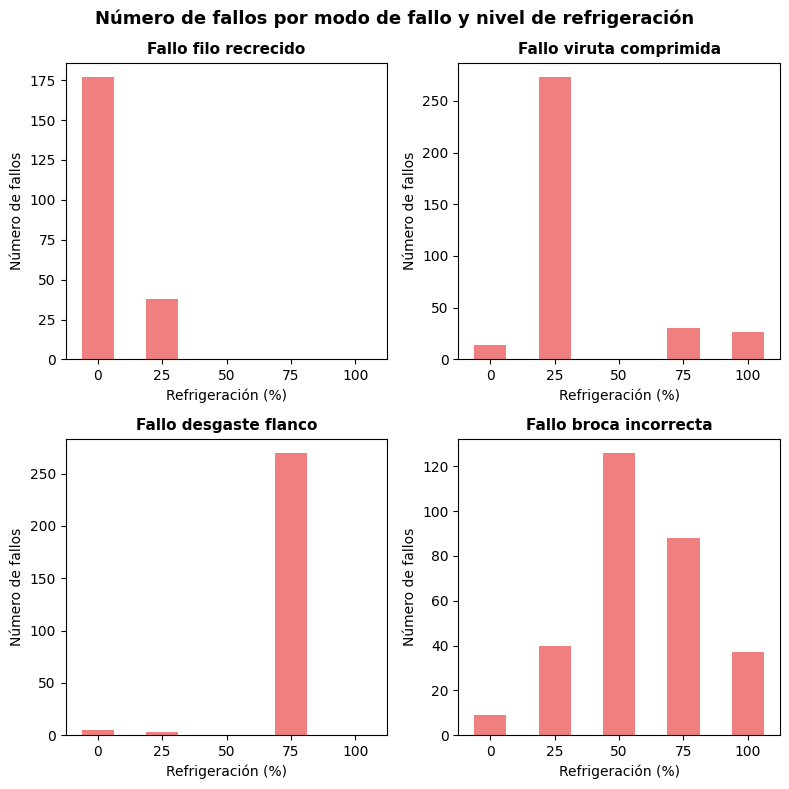

In [37]:
plt.figure(figsize=(8, 8))
niveles = [0, 25, 50, 75, 100]

plt.subplot(2, 2, 1)
taladradora_datos_eda[taladradora_datos_eda['fallo_filo_recrecido'] == 1]['refrigeracion'].value_counts().reindex(niveles, fill_value=0).plot(kind='bar', color='lightcoral')
plt.title('Fallo filo recrecido', fontsize=11, fontweight='bold')
plt.xlabel("Refrigeración (%)")
plt.ylabel("Número de fallos")
plt.xticks(rotation=0)

plt.subplot(2, 2, 2)
taladradora_datos_eda[taladradora_datos_eda['fallo_viruta_comprimida'] == 1]['refrigeracion'].value_counts().reindex(niveles, fill_value=0).plot(kind='bar', color='lightcoral')
plt.title('Fallo viruta comprimida', fontsize=11, fontweight='bold')
plt.xlabel("Refrigeración (%)")
plt.ylabel("Número de fallos")
plt.xticks(rotation=0)

plt.subplot(2, 2, 3)
taladradora_datos_eda[taladradora_datos_eda['fallo_desgaste_flanco'] == 1]['refrigeracion'].value_counts().reindex(niveles, fill_value=0).plot(kind='bar', color='lightcoral')
plt.title('Fallo desgaste flanco', fontsize=11, fontweight='bold')
plt.xlabel("Refrigeración (%)")
plt.ylabel("Número de fallos")
plt.xticks(rotation=0)

plt.subplot(2, 2, 4)
taladradora_datos_eda[taladradora_datos_eda['fallo_broca_incorrecta'] == 1]['refrigeracion'].value_counts().reindex(niveles, fill_value=0).plot(kind='bar', color='lightcoral')
plt.title('Fallo broca incorrecta', fontsize=11, fontweight='bold')
plt.xlabel("Refrigeración (%)")
plt.ylabel("Número de fallos")
plt.xticks(rotation=0)

plt.suptitle('Número de fallos por modo de fallo y nivel de refrigeración', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='2_2_6'></a>
### **2.2.6 Relación entre refrigeración, modos de fallo y materiales**

Se aprecia que el fallo desgaste de flanco se da únicamente para el material N.

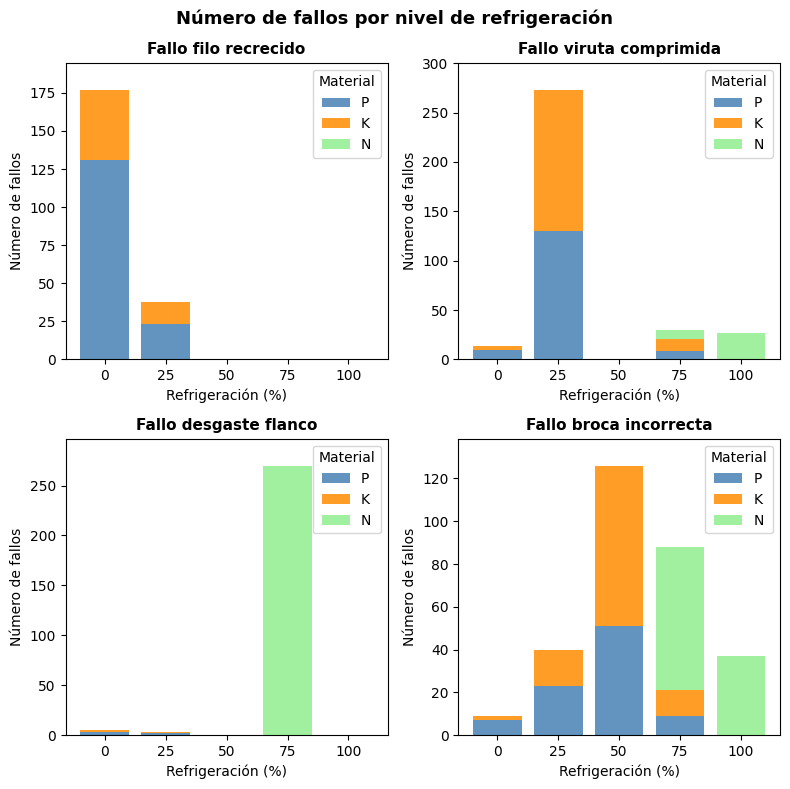

In [38]:
niveles = [0, 25, 50, 75, 100]
colores_material = {'P': 'steelblue', 'K': 'darkorange', 'N': 'lightgreen'}
fallos = ['fallo_filo_recrecido', 'fallo_viruta_comprimida', 'fallo_desgaste_flanco', 'fallo_broca_incorrecta']
titulos = ['Fallo filo recrecido', 'Fallo viruta comprimida', 'Fallo desgaste flanco', 'Fallo broca incorrecta']

plt.figure(figsize=(8, 8))

for i, (fallo, titulo) in enumerate(zip(fallos, titulos)):
    plt.subplot(2, 2, i + 1)
    bottom = [0] * len(niveles)

    for material, color in colores_material.items():
        valores = taladradora_datos_eda[
            (taladradora_datos_eda[fallo] == 1) &
            (taladradora_datos_eda['material'] == material)
        ]['refrigeracion'].value_counts().reindex(niveles, fill_value=0).values

        plt.bar(range(len(niveles)), valores, bottom=bottom, color=color, label=material, alpha=0.85)
        bottom = [b + v for b, v in zip(bottom, valores)]

    plt.ylim(0, max(bottom) * 1.1)  # 10% de margen arriba
    plt.title(titulo, fontsize=11, fontweight='bold')
    plt.xlabel("Refrigeración (%)")
    plt.ylabel("Número de fallos")
    plt.xticks(range(len(niveles)), niveles)
    plt.legend(title='Material')

plt.suptitle('Número de fallos por nivel de refrigeración', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='2_2_7'></a>
### **2.2.7 Relación entre avance y modo de fallo**

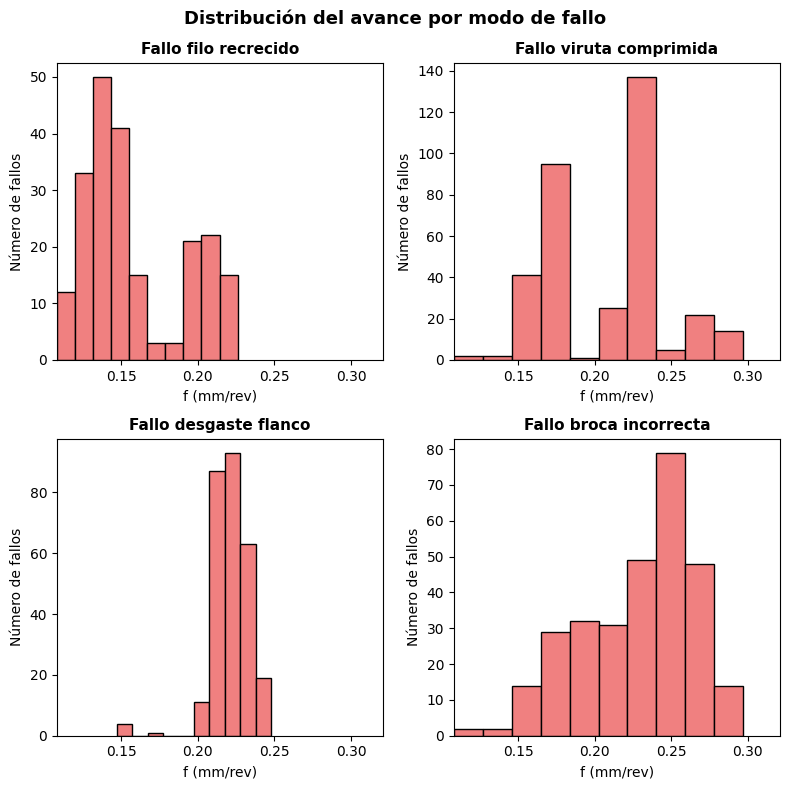

In [39]:
lim_inf_x = taladradora_datos_eda['avance'].min()
lim_sup_x = taladradora_datos_eda['avance'].max()

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
taladradora_datos_eda[taladradora_datos_eda['fallo_filo_recrecido'] == 1]['avance'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo filo recrecido', fontsize=11, fontweight='bold')
plt.xlabel("f (mm/rev)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 2)
taladradora_datos_eda[taladradora_datos_eda['fallo_viruta_comprimida'] == 1]['avance'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo viruta comprimida', fontsize=11, fontweight='bold')
plt.xlabel("f (mm/rev)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 3)
taladradora_datos_eda[taladradora_datos_eda['fallo_desgaste_flanco'] == 1]['avance'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo desgaste flanco', fontsize=11, fontweight='bold')
plt.xlabel("f (mm/rev)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 4)
taladradora_datos_eda[taladradora_datos_eda['fallo_broca_incorrecta'] == 1]['avance'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo broca incorrecta', fontsize=11, fontweight='bold')
plt.xlabel("f (mm/rev)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.suptitle('Distribución del avance por modo de fallo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='2_2_8'></a>
### **2.2.8 Relación entre modo fallo y velocidad de avance**

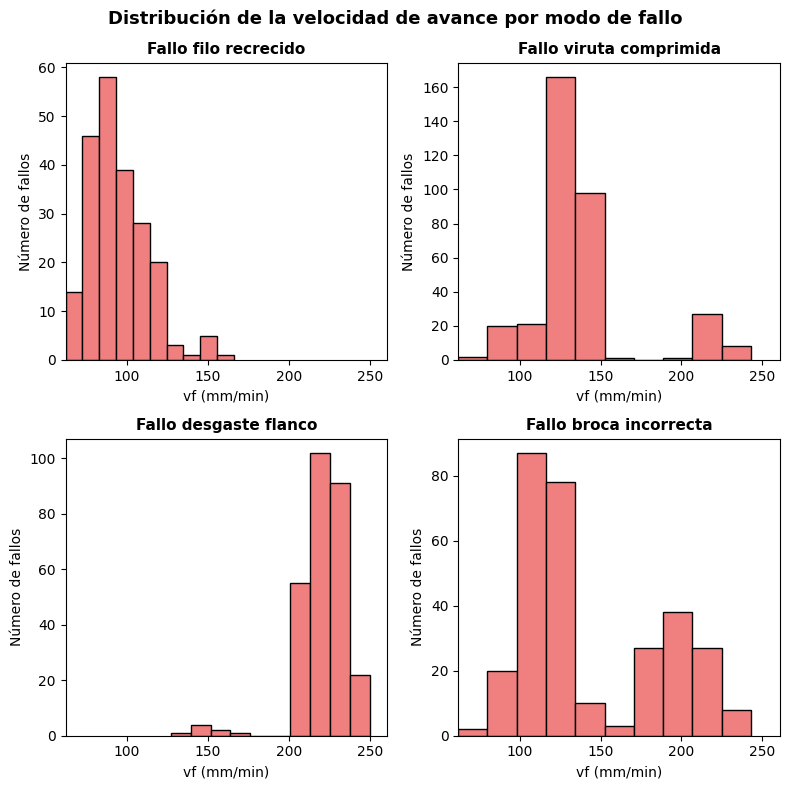

In [40]:
lim_inf_x = taladradora_datos_eda['velocidad_avance'].min()
lim_sup_x = taladradora_datos_eda['velocidad_avance'].max()

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
taladradora_datos_eda[taladradora_datos_eda['fallo_filo_recrecido'] == 1]['velocidad_avance'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo filo recrecido', fontsize=11, fontweight='bold')
plt.xlabel("vf (mm/min)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 2)
taladradora_datos_eda[taladradora_datos_eda['fallo_viruta_comprimida'] == 1]['velocidad_avance'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo viruta comprimida', fontsize=11, fontweight='bold')
plt.xlabel("vf (mm/min)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 3)
taladradora_datos_eda[taladradora_datos_eda['fallo_desgaste_flanco'] == 1]['velocidad_avance'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo desgaste flanco', fontsize=11, fontweight='bold')
plt.xlabel("vf (mm/min)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 4)
taladradora_datos_eda[taladradora_datos_eda['fallo_broca_incorrecta'] == 1]['velocidad_avance'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo broca incorrecta', fontsize=11, fontweight='bold')
plt.xlabel("vf (mm/min)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.suptitle('Distribución de la velocidad de avance por modo de fallo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='2_2_9'></a>
### **2.2.9 Relación entre modo de fallo y potencia de corte**

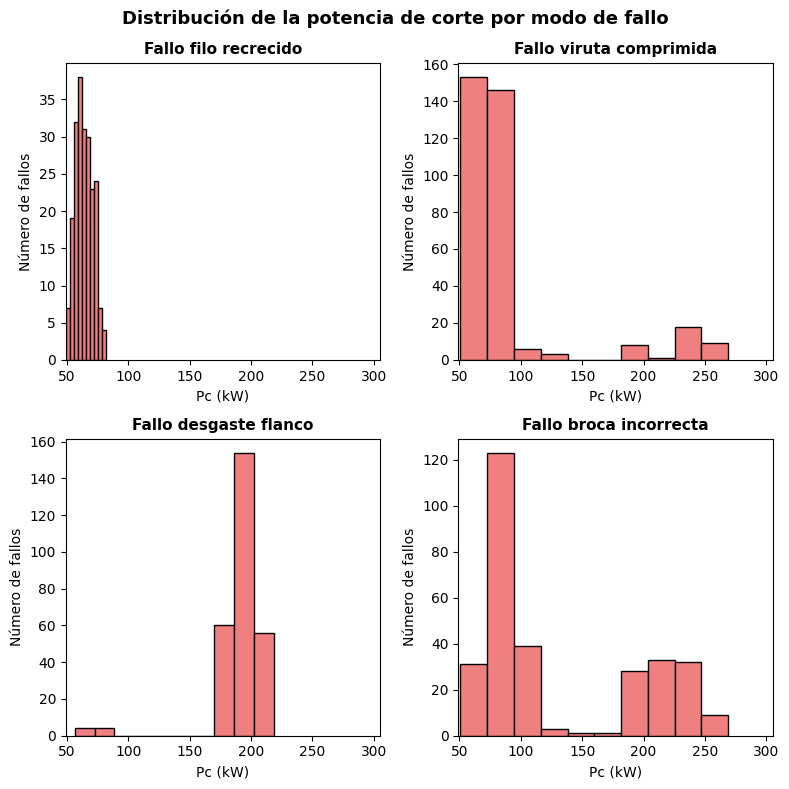

In [41]:
lim_inf_x = taladradora_datos_eda['potencia_corte'].min()
lim_sup_x = taladradora_datos_eda['potencia_corte'].max()

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
taladradora_datos_eda[taladradora_datos_eda['fallo_filo_recrecido'] == 1]['potencia_corte'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo filo recrecido', fontsize=11, fontweight='bold')
plt.xlabel("Pc (kW)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 2)
taladradora_datos_eda[taladradora_datos_eda['fallo_viruta_comprimida'] == 1]['potencia_corte'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo viruta comprimida', fontsize=11, fontweight='bold')
plt.xlabel("Pc (kW)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 3)
taladradora_datos_eda[taladradora_datos_eda['fallo_desgaste_flanco'] == 1]['potencia_corte'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo desgaste flanco', fontsize=11, fontweight='bold')
plt.xlabel("Pc (kW)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 4)
taladradora_datos_eda[taladradora_datos_eda['fallo_broca_incorrecta'] == 1]['potencia_corte'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo broca incorrecta', fontsize=11, fontweight='bold')
plt.xlabel("Pc (kW)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.suptitle('Distribución de la potencia de corte por modo de fallo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

A pesar de la elevada correlación que presentan las variables potencia de corte y velocidad de avance, no aportan la misma informacion. Los modelos empeoran considerablemente al eliminar la velocidad de avance como variable predictora puesto que no son capaces de distinguir los modos de fallo correctamente, especialmente para los modos de fallo desgaste de flanco y viruta comprimida.

<a id='2_2_10'></a>
### **2.2.10 Relación entre modo de fallo y velocidad de corte**

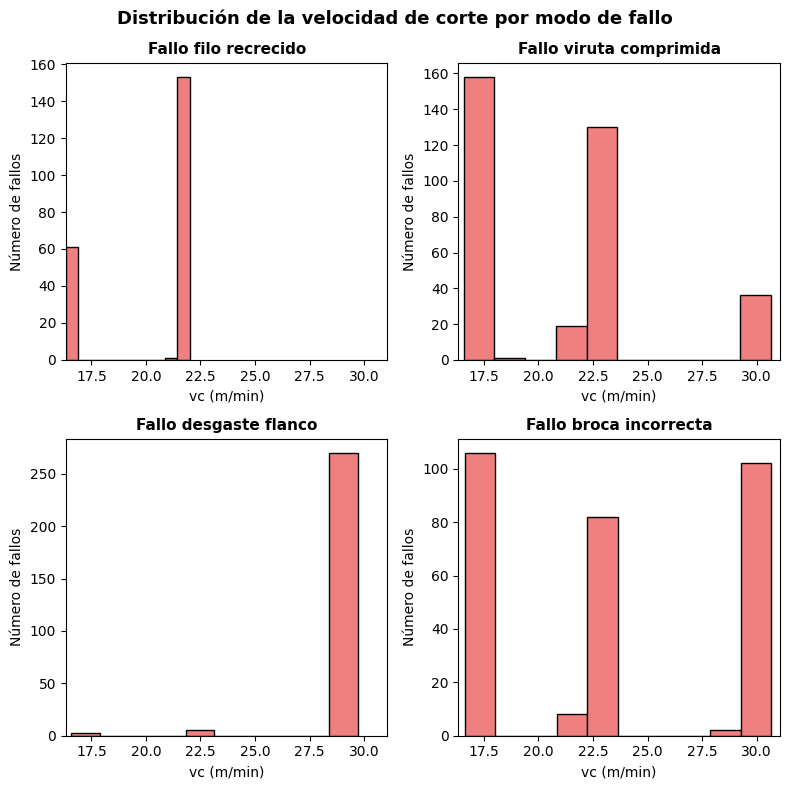

In [42]:
lim_inf_x = taladradora_datos_eda['velocidad_corte'].min()
lim_sup_x = taladradora_datos_eda['velocidad_corte'].max()

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
taladradora_datos_eda[taladradora_datos_eda['fallo_filo_recrecido'] == 1]['velocidad_corte'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo filo recrecido', fontsize=11, fontweight='bold')
plt.xlabel("vc (m/min)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 2)
taladradora_datos_eda[taladradora_datos_eda['fallo_viruta_comprimida'] == 1]['velocidad_corte'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo viruta comprimida', fontsize=11, fontweight='bold')
plt.xlabel("vc (m/min)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 3)
taladradora_datos_eda[taladradora_datos_eda['fallo_desgaste_flanco'] == 1]['velocidad_corte'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo desgaste flanco', fontsize=11, fontweight='bold')
plt.xlabel("vc (m/min)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 4)
taladradora_datos_eda[taladradora_datos_eda['fallo_broca_incorrecta'] == 1]['velocidad_corte'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo broca incorrecta', fontsize=11, fontweight='bold')
plt.xlabel("vc (m/min)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.suptitle('Distribución de la velocidad de corte por modo de fallo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='2_2_11'></a>
### **2.2.11 Relación entre modo de fallo y tiempo de proceso**

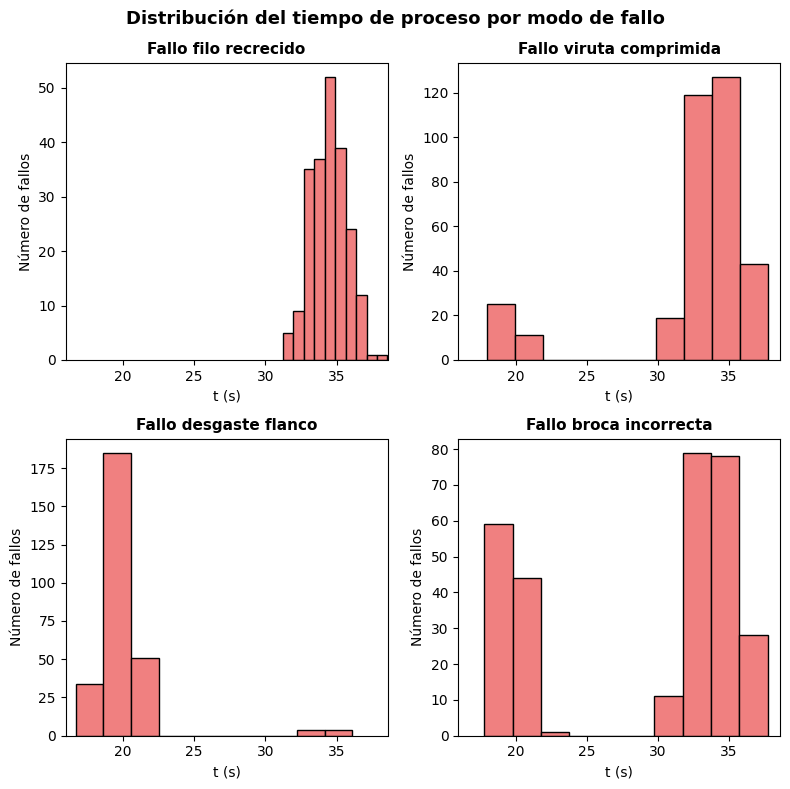

In [43]:
lim_inf_x = taladradora_datos_eda['tiempo_proceso'].min()
lim_sup_x = taladradora_datos_eda['tiempo_proceso'].max()

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
taladradora_datos_eda[taladradora_datos_eda['fallo_filo_recrecido'] == 1]['tiempo_proceso'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo filo recrecido', fontsize=11, fontweight='bold')
plt.xlabel("t (s)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 2)
taladradora_datos_eda[taladradora_datos_eda['fallo_viruta_comprimida'] == 1]['tiempo_proceso'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo viruta comprimida', fontsize=11, fontweight='bold')
plt.xlabel("t (s)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 3)
taladradora_datos_eda[taladradora_datos_eda['fallo_desgaste_flanco'] == 1]['tiempo_proceso'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo desgaste flanco', fontsize=11, fontweight='bold')
plt.xlabel("t (s)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.subplot(2, 2, 4)
taladradora_datos_eda[taladradora_datos_eda['fallo_broca_incorrecta'] == 1]['tiempo_proceso'].plot(kind='hist', color='lightcoral', edgecolor='black')
plt.title('Fallo broca incorrecta', fontsize=11, fontweight='bold')
plt.xlabel("t (s)")
plt.ylabel("Número de fallos")
plt.xlim(lim_inf_x, lim_sup_x)

plt.suptitle('Distribución del tiempo de proceso por modo de fallo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='3'></a>
# **3. Preprocesamiento e ingeniería de características (*Data Preprocessing*)**
---

Se modifica la variable taladradora_datos eliminando las variables que se han indicado.


<a id='3_1'></a>
## **3.1 Selección de variables (*Feature Selection*)**

Variables que tienen correlación con los fallos, identificadas a través de la matriz de correlaciones del EDA.


No se incluye la velocidad del husillo porque tiene correlación perfecta con velocidad de corte y tampoco id porque es solo un identificador (no aporta información relevante para la predicción de los fallos).

In [44]:
# 1. Selección de variables
columnas_a_eliminar_modelo = ['id','velocidad_husillo']

df_modelo = taladradora_datos_eda.drop(columns=columnas_a_eliminar_modelo)
# Variables de predicción numéricas
variables_numericas = [
    'velocidad_corte',
    'avance',
    'velocidad_avance',
    'potencia_corte',
    'refrigeracion',
    'tiempo_proceso'
]

# Variables de predicción categóricas
variables_categoricas = ['material', 'tipo_broca']

# Variables objetivo que se quiere predecir
variables_objetivo = [
    'fallo_filo_recrecido',
    'fallo_viruta_comprimida',
    'fallo_desgaste_flanco',
    'fallo_broca_incorrecta'
]

# Imprimir resumen
print(f"\n- Variables numéricas: {len(variables_numericas)}")
print(f"- Variables categóricas: {len(variables_categoricas)}")
print(f"- Variables objetivo: {len(variables_objetivo)}")


- Variables numéricas: 6
- Variables categóricas: 2
- Variables objetivo: 4


<a id='3_2'></a>
## **3.2 Codificación de las variables categóricas y separación de variables (*Encoding*)**

Se codifican las variables categóricas usando OneHotEncoder (Scikit-Learn).

Se transforman las variables categóricas (material y tipo_broca) en columnas binarias. De esta forma, los modelos son capaces de procesarlas.

In [45]:
# 2. Codificación de variables categóricas usando OneHotEncoder de scikit-learn
encoder = OneHotEncoder(sparse_output=False, dtype=int, handle_unknown='ignore')

# Ajustar y transformar las variables categóricas
categoricas_encoded = encoder.fit_transform(df_modelo[variables_categoricas])

# Obtener nombres de las columnas generadas
categoricas_nombres = encoder.get_feature_names_out(variables_categoricas)

# Crear dataframe con las variables numéricas + categóricas codificadas
df_encoded = pd.DataFrame(
    np.hstack([df_modelo[variables_numericas].values, categoricas_encoded]),
    columns=variables_numericas + list(categoricas_nombres)
)

<a id='3_3'></a>
## **3.3 Separar X e y (*Train/Test Split*)**
Se comprueba que tras la separación de las variables categóricas (X) y las variables objetivo (y) coinciden en número de filas.

In [46]:
# 3. Separar X e y
X = df_encoded
y = df_modelo[variables_objetivo].reset_index(drop=True)

print(f"\nDimensiones")
print(f"- X shape: {X.shape}")
print(f"- y shape: {y.shape}")

# Verificar distribución de cada objetivo
print("\nDistribución de variables objetivo:")
for col in variables_objetivo:
    conteo = y[col].value_counts()
    porcentaje = (conteo[1] / len(df_modelo)) * 100
    print(f"  {col:25s}: {conteo[1]:4d} casos ({porcentaje:.2f}%)")


Dimensiones
- X shape: (20000, 12)
- y shape: (20000, 4)

Distribución de variables objetivo:
  fallo_filo_recrecido     :  215 casos (1.07%)
  fallo_viruta_comprimida  :  344 casos (1.72%)
  fallo_desgaste_flanco    :  278 casos (1.39%)
  fallo_broca_incorrecta   :  300 casos (1.50%)


<a id='3_4'></a>
## **3.4 Suprimir los casos con fallos simultáneos (*Cleaning*)**

Para simplificar el problema se eliminan los casos con fallos simultáneos, que representan un porcentaje muy bajo del dataset (0.57% del dataset). De esta forma, el problema pasa de ser clasificación multilabel a clasificación multiclase. Esto permite aplicar técnicas de balanceo y una comparación más sencilla entre los algoritmos de aprendizaje automático.

In [47]:
# 4. Eliminar casos con fallos simultáneos
mask = y.sum(axis=1) <= 1
X = X[mask]
y = y[mask]

print(f"Número de muestras antes:        {mask.shape[0]}")
print(f"Número de muestras después:      {mask.sum()}")
print(f"Número de muestras eliminadas:   {(~mask).sum()}")

Número de muestras antes:        20000
Número de muestras después:      19886
Número de muestras eliminadas:   114


<a id='3_5'></a>
## **3.5 Conversión de *y* a multiclase (*Multiclass Conversion*)**

In [48]:
# 5. Convertir y a multiclase
def asignar_clase(row):
    if row.sum() == 0:
        return 'sin_fallo'
    return row.idxmax()

y_single = y.apply(asignar_clase, axis=1)
print(y_single.value_counts())

sin_fallo                  18999
fallo_desgaste_flanco        261
fallo_viruta_comprimida      230
fallo_filo_recrecido         202
fallo_broca_incorrecta       194
Name: count, dtype: int64


<a id='3_6'></a>
## **3.6 División para entrenamiento y prueba (*Train/Test Split*)**

In [49]:
# 6. Dividir para entrenamiento y prueba
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_single,
    test_size=0.2,
    random_state=42,
)

print(f"Número de muestras de entrenamiento:     {X_train.shape[0]}")
print(f"Número de muestras de prueba:            {X_test.shape[0]}")

Número de muestras de entrenamiento:     15908
Número de muestras de prueba:            3978


<a id='3_7'></a>
## **3.7 Normalización de los datos (*Scaling*)**

In [50]:
# 7. Estandarizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<a id='3_8'></a>
## **3.8 Tratamiento de datasets desbalanceados (*Handling Imbalance Dataset and Cleaning*)**

AplicacIón de SMOTETomek (sobremuestreo + limpieza)

In [51]:
# 8. Técnica de balanceo de datos
# SMOTETomek
smt = SMOTETomek(random_state=42)
X_train_bal, y_train_bal = smt.fit_resample(X_train_scaled, y_train)

# comparar distribución de fallos antes y después
print(f"\nAntes: {X_train.shape}")
print(f"Después: {X_train_bal.shape}")
print("\nDistribución DESPUÉS:")
print(pd.Series(y_train_bal).value_counts())


Antes: (15908, 12)
Después: (76016, 12)

Distribución DESPUÉS:
fallo_desgaste_flanco      15204
fallo_broca_incorrecta     15204
fallo_viruta_comprimida    15203
fallo_filo_recrecido       15203
sin_fallo                  15202
Name: count, dtype: int64


<a id='3_9'></a>
## **3.9 Codificación de las variables (LabelEncoder)**

In [52]:
# 9. "encodear" y_train_bal + y_test
# XGBoost y red neuronal MLP requieren etiquetas numéricas
le = LabelEncoder()
y_train_bal_enc = le.fit_transform(y_train_bal)
y_test_enc = le.transform(y_test)

<a id='4'></a>
# **4. Modelado y evaluación comparativa (*Modelling & Evaluation*)**
---

<a id='4_1'></a>
## **4.1 Entrenamiento de modelos y métricas (*Model Training*)**

<a id='4_2'></a>
## **4.2 Algoritmos implementados**

<a id='4_2_1'></a>
### **4.2.1 Regresión logística (*Logistic Regression*)**

Con este modelo se puede evaluar si es necesaria la complejidad de modelos no lineales (RF, XGBoost) y redes neuronales para la predicción de los tipos de fallo. De esta forma, se comprueba si aportan mejoras significativas frente a un modelo lineal simple.

In [53]:
# PASO 1: definir modelos
modelo_lr_0_default = LogisticRegression(
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)
modelo_lr_1_base = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    penalty='l2',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
modelo_lr_2_robusta = LogisticRegression(
    C=0.1,
    solver='saga',
    penalty='l1',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
modelo_lr_3_compleja = LogisticRegression(
    C=10,
    solver='saga',
    penalty='l2',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)


In [54]:
# PASO 2: entrenar
modelos_lr = {
    'default':  modelo_lr_0_default,
    'base':     modelo_lr_1_base,
    'robusta':  modelo_lr_2_robusta,
    'compleja': modelo_lr_3_compleja
}

for nombre, modelo in modelos_lr.items():
    print(f"Entrenando RL {nombre}...")
    modelo.fit(X_train_bal, y_train_bal)

print("\nFin del entrenamiento.")

Entrenando RL default...
Entrenando RL base...
Entrenando RL robusta...
Entrenando RL compleja...

Fin del entrenamiento.


In [55]:
# PASO 3: evaluación
for nombre, modelo in modelos_lr.items():
    print(f"\n{'='*64}")
    print(f"CONFIGURACIÓN: {nombre.upper()}")
    print(f"{'='*64}")
    y_pred = modelo.predict(X_test_scaled)
    print(classification_report(y_test, y_pred))


CONFIGURACIÓN: DEFAULT
                         precision    recall  f1-score   support

 fallo_broca_incorrecta       0.01      0.55      0.03        42
  fallo_desgaste_flanco       0.92      1.00      0.96        54
   fallo_filo_recrecido       0.17      1.00      0.29        29
fallo_viruta_comprimida       0.79      1.00      0.89        58
              sin_fallo       0.99      0.54      0.70      3795

               accuracy                           0.56      3978
              macro avg       0.58      0.82      0.57      3978
           weighted avg       0.97      0.56      0.70      3978


CONFIGURACIÓN: BASE
                         precision    recall  f1-score   support

 fallo_broca_incorrecta       0.02      0.62      0.03        42
  fallo_desgaste_flanco       0.87      1.00      0.93        54
   fallo_filo_recrecido       0.12      1.00      0.21        29
fallo_viruta_comprimida       0.81      1.00      0.89        58
              sin_fallo       0.99      0

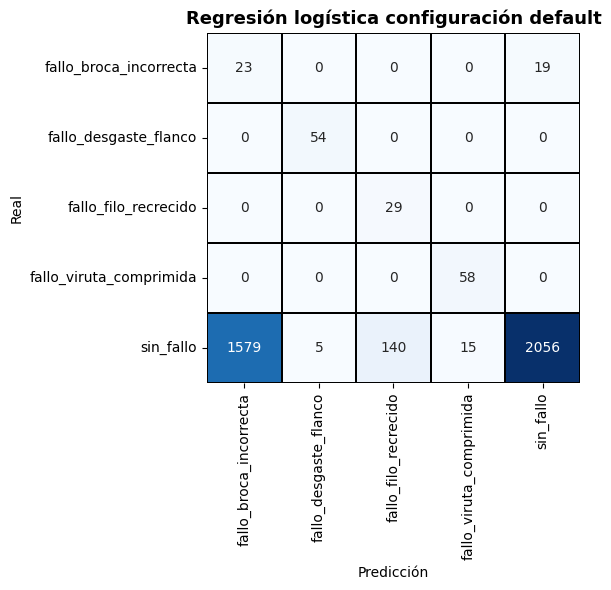

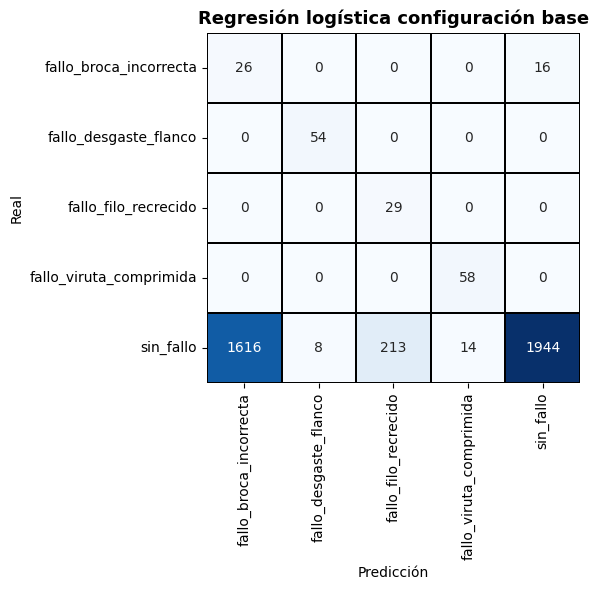

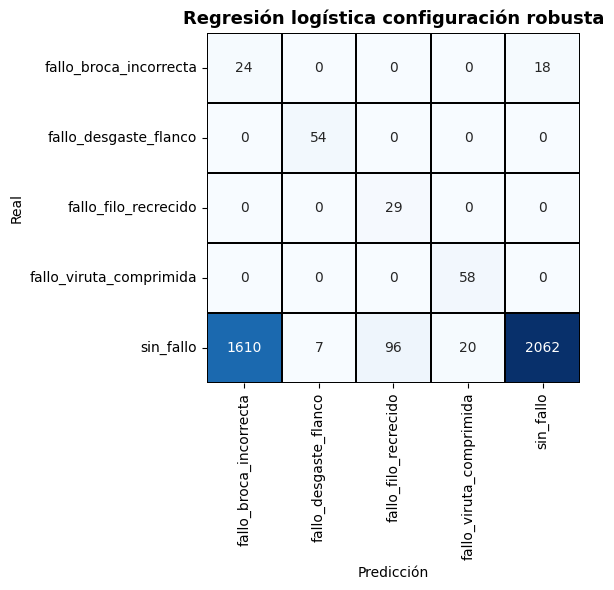

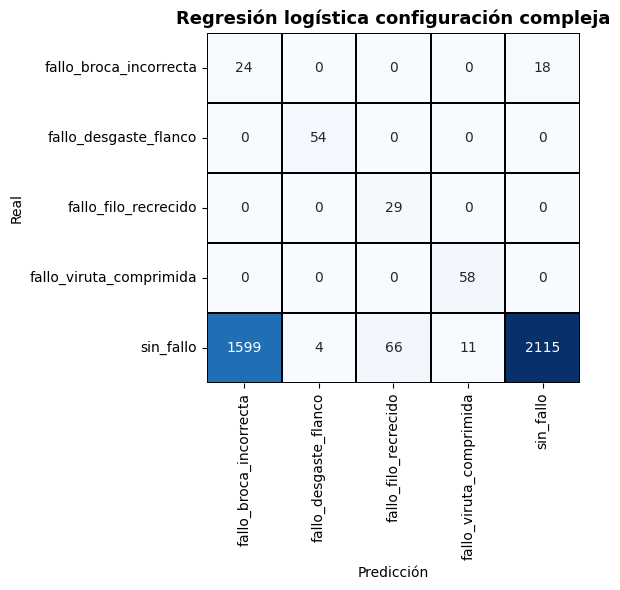

In [56]:
# PASO 4: matrices de confusión
for nombre, modelo in modelos_lr.items():
    y_pred = modelo.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=modelo.classes_,
                yticklabels=modelo.classes_,
                cbar=False, linewidths=0.15, linecolor='black')
    ax.set_title(f'Regresión logística configuración {nombre}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    plt.tight_layout()
    plt.show()
    print("\n")

A pesar de aplicar SMOTETomek para balancear el entrenamiento, en producción real los fallos son minoritarios. Por ello, se realiza la evaluación con *recall macro*, que penaliza igual un fallo no detectado independientemente de su frecuencia. No detectar un fallo conlleva mayores costes que detectar un falso positivo.

In [57]:
# PASO 5: tabla comparativa
resumen_lr = {}

for nombre, modelo in modelos_lr.items():
    y_pred = modelo.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True)
    resumen_lr[nombre] = {
        'accuracy':        report['accuracy'],
        'f1_macro':        report['macro avg']['f1-score'],
        'recall_macro':    report['macro avg']['recall'],
        'precision_macro': report['macro avg']['precision']
    }

df_resumen_lr = pd.DataFrame(resumen_lr).T.round(4)
print("\n" + "="*59)
print("COMPARATIVA ENTRE CONFIGURACIONES — REGRESIÓN LOGÍSTICA")
print("="*59)
print(df_resumen_lr.to_string())

mejor_lr = df_resumen_lr['recall_macro'].idxmax()
print(f"\nMejor configuración: {mejor_lr.upper()}")


COMPARATIVA ENTRE CONFIGURACIONES — REGRESIÓN LOGÍSTICA
          accuracy  f1_macro  recall_macro  precision_macro
default     0.5581    0.5725        0.8179           0.5773
base        0.5307    0.5488        0.8263           0.5608
robusta     0.5598    0.5799        0.8230           0.5734
compleja    0.5732    0.6176        0.8257           0.6166

Mejor configuración: BASE


<a id='4_2_2'></a>
### **4.2.2 Bosque aleatorio (*Random Forest*)**

In [58]:
# PASO 1: definir modelos
modelo_rf_0_simple = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
modelo_rf_1_default = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
modelo_rf_2_robusto = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
modelo_rf_3_complejo = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [59]:
# PASO 2: entrenar
# Uso de diccionarios
modelos_rf = {
    'simple':   modelo_rf_0_simple,
    'default':  modelo_rf_1_default,
    'robusta':  modelo_rf_2_robusto,
    'compleja': modelo_rf_3_complejo
}

for nombre, modelo in modelos_rf.items():
    modelo.verbose = 0
    print(f"Entrenando RF {nombre}...")
    modelo.fit(X_train_bal, y_train_bal)

print("\nFin del entrenamiento.")

Entrenando RF simple...
Entrenando RF default...
Entrenando RF robusta...
Entrenando RF compleja...

Fin del entrenamiento.


In [60]:
# PASO 3: evaluación
for nombre, modelo in modelos_rf.items():
    modelo.verbose = 0
    print(f"\n{'='*64}")
    print(f"CONFIGURACIÓN: {nombre.upper()}")
    print(f"{'='*64}")

    y_pred = modelo.predict(X_test_scaled)

    print(classification_report(y_test, y_pred))


CONFIGURACIÓN: SIMPLE
                         precision    recall  f1-score   support

 fallo_broca_incorrecta       0.03      0.95      0.05        42
  fallo_desgaste_flanco       0.64      1.00      0.78        54
   fallo_filo_recrecido       0.11      1.00      0.19        29
fallo_viruta_comprimida       0.12      1.00      0.22        58
              sin_fallo       1.00      0.41      0.58      3795

               accuracy                           0.44      3978
              macro avg       0.38      0.87      0.36      3978
           weighted avg       0.96      0.44      0.57      3978


CONFIGURACIÓN: DEFAULT
                         precision    recall  f1-score   support

 fallo_broca_incorrecta       1.00      1.00      1.00        42
  fallo_desgaste_flanco       1.00      1.00      1.00        54
   fallo_filo_recrecido       1.00      0.97      0.98        29
fallo_viruta_comprimida       0.97      0.98      0.97        58
              sin_fallo       1.00     

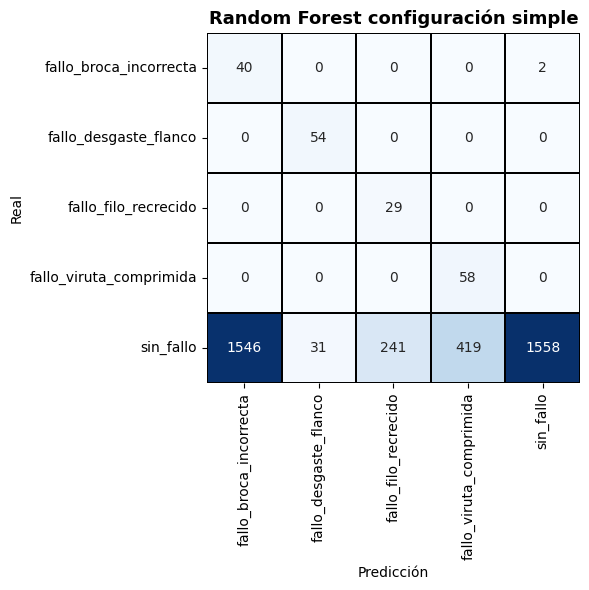

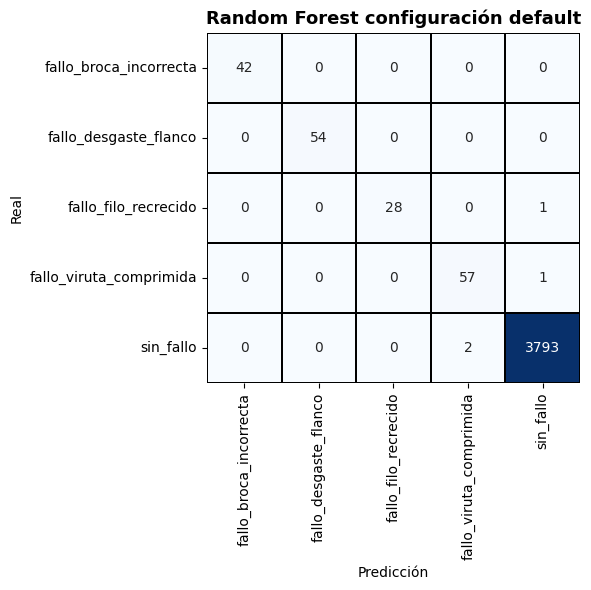

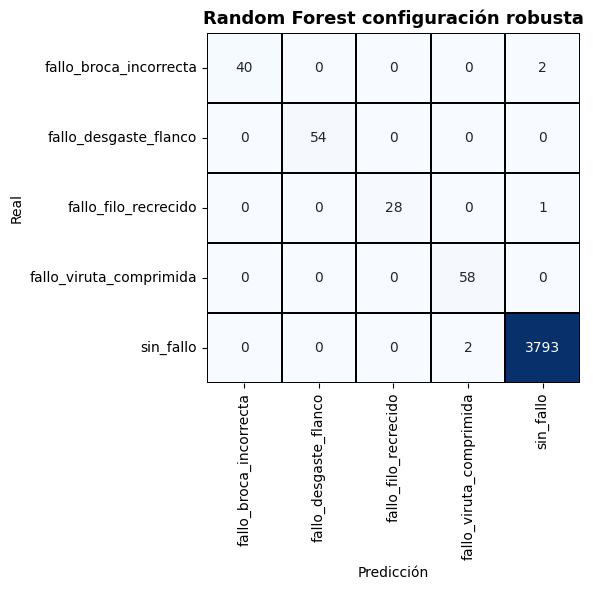

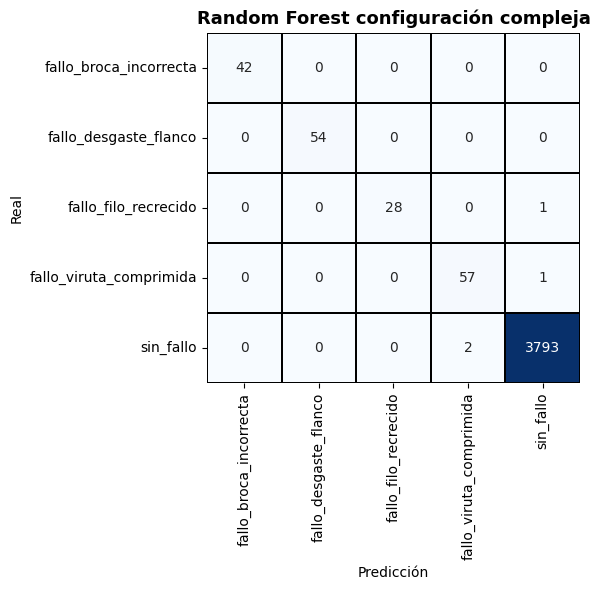

In [61]:
# PASO 4: matrices de confusión
for nombre, modelo in modelos_rf.items():
    modelo.verbose = 0
    y_pred = modelo.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=modelo.classes_,
                yticklabels=modelo.classes_,
                cbar=False, linewidths=0.15, linecolor='black')
    ax.set_title(f'Random Forest configuración {nombre}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    plt.tight_layout()
    plt.show()
    print("\n")

In [62]:
# PASO 5: tabla comparativa
resumen_rf = {}
for nombre, modelo in modelos_rf.items():
    modelo.verbose = 0
    y_pred = modelo.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True)
    resumen_rf[nombre] = {
        'accuracy':        report['accuracy'],
        'f1_macro':        report['macro avg']['f1-score'],
        'recall_macro':    report['macro avg']['recall'],
        'precision_macro': report['macro avg']['precision']
    }

df_resumen_rf = pd.DataFrame(resumen_rf).T.round(4)
print("\n" + "="*60)
print("COMPARATIVA ENTRE CONFIGURACIONES — RANDOM FOREST")
print("="*60)
print(df_resumen_rf.to_string())

# identificar el mejor modelo por recall_macro
mejor_rf = df_resumen_rf['recall_macro'].idxmax()
print(f"\nMejor configuración: {mejor_rf.upper()}")


COMPARATIVA ENTRE CONFIGURACIONES — RANDOM FOREST
          accuracy  f1_macro  recall_macro  precision_macro
simple      0.4372    0.3638        0.8726           0.3776
default     0.9990    0.9913        0.9895           0.9931
robusta     0.9987    0.9881        0.9835           0.9932
compleja    0.9990    0.9913        0.9895           0.9931

Mejor configuración: DEFAULT


<a id='4_2_3'></a>
### **4.2.3 XGBoost**

In [63]:
# PASO 1: definir modelos
modelo_xgb_0_default = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
modelo_xgb_1_base = XGBClassifier(
    n_estimators=50,
    max_depth=6,
    learning_rate=0.3,
    subsample=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
modelo_xgb_2_robusto = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
modelo_xgb_3_complejo = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

In [64]:
# PASO 2: entrenar
modelos_xgb = {
    'default':  modelo_xgb_0_default,
    'base':     modelo_xgb_1_base,
    'robusta':  modelo_xgb_2_robusto,
    'compleja': modelo_xgb_3_complejo
}

for nombre, modelo in modelos_xgb.items():
    print(f"Entrenando XGBoost {nombre}...")
    modelo.fit(X_train_bal, y_train_bal_enc)

print("\nFin del entrenamiento.")

Entrenando XGBoost default...
Entrenando XGBoost base...
Entrenando XGBoost robusta...
Entrenando XGBoost compleja...

Fin del entrenamiento.


In [65]:
# PASO 3: evaluación
for nombre, modelo in modelos_xgb.items():
    print(f"\n{'='*64}")
    print(f"CONFIGURACIÓN: {nombre.upper()}")
    print(f"{'='*64}")
    y_pred_enc = modelo.predict(X_test_scaled)
    y_pred = le.inverse_transform(y_pred_enc)
    print(classification_report(y_test, y_pred))


CONFIGURACIÓN: DEFAULT
                         precision    recall  f1-score   support

 fallo_broca_incorrecta       1.00      1.00      1.00        42
  fallo_desgaste_flanco       1.00      1.00      1.00        54
   fallo_filo_recrecido       0.80      0.97      0.88        29
fallo_viruta_comprimida       0.97      1.00      0.98        58
              sin_fallo       1.00      1.00      1.00      3795

               accuracy                           1.00      3978
              macro avg       0.95      0.99      0.97      3978
           weighted avg       1.00      1.00      1.00      3978


CONFIGURACIÓN: BASE
                         precision    recall  f1-score   support

 fallo_broca_incorrecta       1.00      1.00      1.00        42
  fallo_desgaste_flanco       1.00      1.00      1.00        54
   fallo_filo_recrecido       0.79      0.93      0.86        29
fallo_viruta_comprimida       0.97      1.00      0.98        58
              sin_fallo       1.00      1

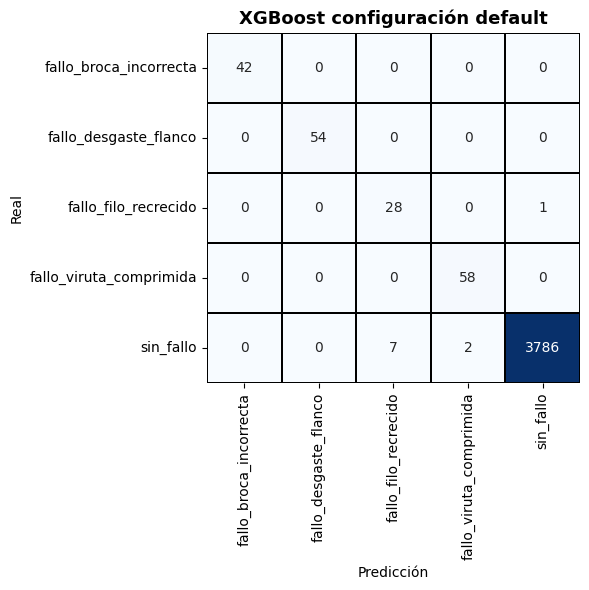

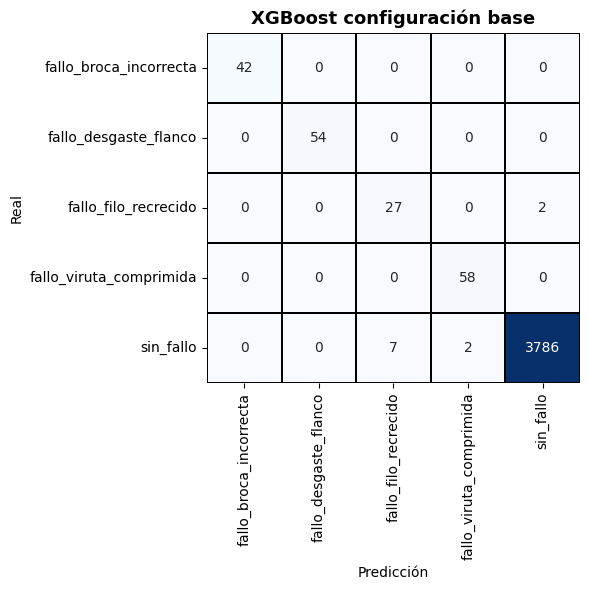

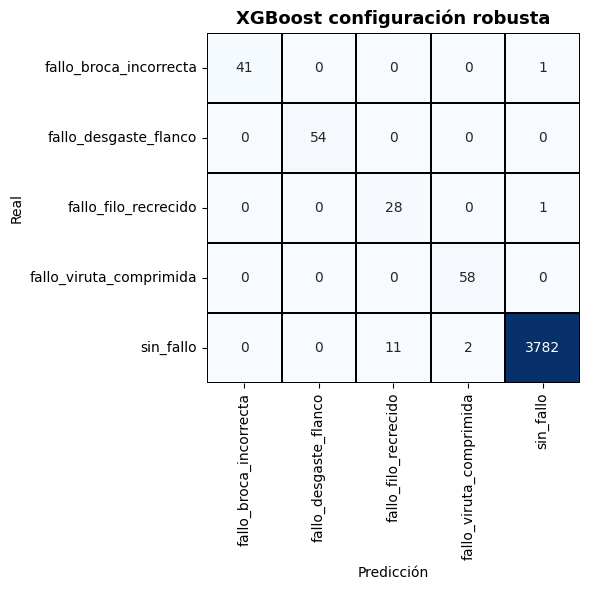

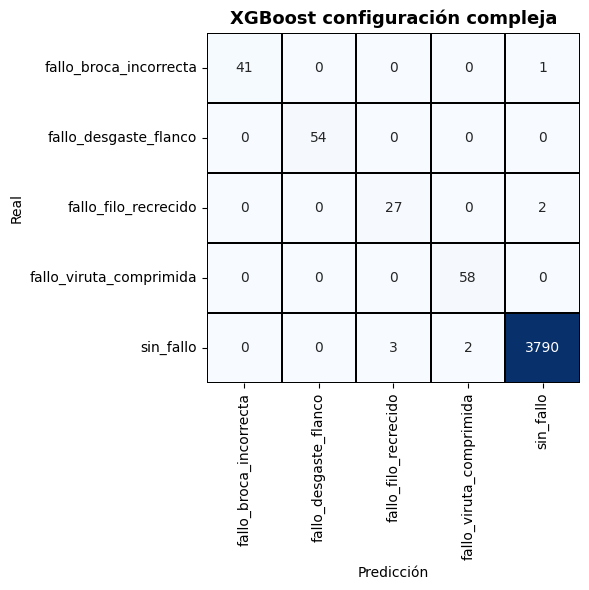

In [66]:
# PASO 4: matrices de confusión
for nombre, modelo in modelos_xgb.items():
    y_pred_enc = modelo.predict(X_test_scaled)
    y_pred = le.inverse_transform(y_pred_enc)

    cm = confusion_matrix(y_test, y_pred, labels=le.classes_)

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                cbar=False, linewidths=0.15, linecolor='black')
    ax.set_title(f'XGBoost configuración {nombre}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    plt.tight_layout()
    plt.show()
    print("\n")

In [67]:
# PASO 5: tabla comparativa
resumen_xgb = {}

for nombre, modelo in modelos_xgb.items():
    y_pred_enc = modelo.predict(X_test_scaled)
    y_pred = le.inverse_transform(y_pred_enc)
    report = classification_report(y_test, y_pred, output_dict=True)
    resumen_xgb[nombre] = {
        'accuracy':        report['accuracy'],
        'f1_macro':        report['macro avg']['f1-score'],
        'recall_macro':    report['macro avg']['recall'],
        'precision_macro': report['macro avg']['precision']
    }

df_resumen_xgb = pd.DataFrame(resumen_xgb).T.round(4)
print("\n" + "="*60)
print("COMPARATIVA ENTRE CONFIGURACIONES — XGBOOST")
print("="*60)
print(df_resumen_xgb.to_string())

mejor_xgb = df_resumen_xgb['recall_macro'].idxmax()
print(f"\nMejor configuración: {mejor_xgb.upper()}")


COMPARATIVA ENTRE CONFIGURACIONES — XGBOOST
          accuracy  f1_macro  recall_macro  precision_macro
default     0.9975    0.9713        0.9926           0.9533
base        0.9972    0.9677        0.9857           0.9521
robusta     0.9962    0.9585        0.9877           0.9368
compleja    0.9980    0.9770        0.9812           0.9732

Mejor configuración: DEFAULT


<a id='4_2_4'></a>
### **4.2.4 Red neuronal artificial (*Neural Network MLP*)**

In [68]:
#import tensorflow as tf
print(tf.__version__)

2.20.0


En las redes neuronales existe una variabilidad inherente. Por tanto, los resultados que se presentan en este código son representativos y variarán cada vez que se ejecute nuevamente el código.

In [69]:
# RED NEURONAL — KERAS
# Fijar semilla para reproducibilidad y que las fuentes de aletoriedad sean menores
os.environ['PYTHONHASHSEED'] = '42'
np.random.seed(42)
tf.random.set_seed(42)

# Las etiquetas deben ser numéricas (=> le)
# y_train_bal_enc e y_test_enc ya definidos

# PASO 1: definir arquitecturas
def crear_modelo_base():
    modelo = keras.Sequential([
        layers.Input(shape=(12,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(5, activation='softmax')
    ])
    modelo.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return modelo

def crear_modelo_robusto():
    modelo = keras.Sequential([
        layers.Input(shape=(12,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(5, activation='softmax')
    ])
    modelo.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return modelo

def crear_modelo_complejo():
    modelo = keras.Sequential([
        layers.Input(shape=(12,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(5, activation='softmax')
    ])
    modelo.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return modelo

In [70]:
# PASO 2: entrenar
historiales = {}

modelos_nn = {
    'base':     crear_modelo_base(),
    'robusta':  crear_modelo_robusto(),
    'compleja': crear_modelo_complejo()
}

for nombre, modelo in modelos_nn.items():
    print(f"\nEntrenando MLP {nombre}...")
    historial = modelo.fit(
        X_train_bal, y_train_bal_enc,
        epochs=20,
        batch_size=256,
        validation_split=0.1,
        verbose=1
    )
    historiales[nombre] = historial

print("\nFin del entrenamiento.")


Entrenando MLP base...
Epoch 1/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8710 - loss: 0.4226 - val_accuracy: 1.0000 - val_loss: 0.1365
Epoch 2/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9750 - loss: 0.0854 - val_accuracy: 1.0000 - val_loss: 0.0451
Epoch 3/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9793 - loss: 0.0674 - val_accuracy: 1.0000 - val_loss: 0.0314
Epoch 4/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9817 - loss: 0.0583 - val_accuracy: 1.0000 - val_loss: 0.0266
Epoch 5/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9836 - loss: 0.0517 - val_accuracy: 1.0000 - val_loss: 0.0205
Epoch 6/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9852 - loss: 0.0464 - val_accuracy: 1.0000 - val_loss: 0.0159
Epoch 7/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9866 - loss: 0.0417 - val_accuracy: 1.0000 - val_loss: 0.0135
Epoch 8/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9880 - loss: 0

In [71]:
# PASO 3: evaluación
for nombre, modelo in modelos_nn.items():
    print(f"\n{'='*64}")
    print(f"CONFIGURACIÓN: {nombre.upper()}")
    print(f"{'='*64}")

    y_pred_enc = modelo.predict(X_test_scaled).argmax(axis=1)
    y_pred = le.inverse_transform(y_pred_enc)

    print(classification_report(y_test, y_pred))


CONFIGURACIÓN: BASE
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
                         precision    recall  f1-score   support

 fallo_broca_incorrecta       1.00      1.00      1.00        42
  fallo_desgaste_flanco       0.96      1.00      0.98        54
   fallo_filo_recrecido       0.42      1.00      0.59        29
fallo_viruta_comprimida       0.94      1.00      0.97        58
              sin_fallo       1.00      0.99      0.99      3795

               accuracy                           0.99      3978
              macro avg       0.86      1.00      0.91      3978
           weighted avg       0.99      0.99      0.99      3978


CONFIGURACIÓN: ROBUSTA
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
                         precision    recall  f1-score   support

 fallo_broca_incorrecta       1.00      1.00      1.00        42
  fallo_desgaste_flanco       0.96      1.00      0.98        54
   fallo_filo_recrecido       0.41      1.00      0.59        29
fallo_viruta_comprim

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step


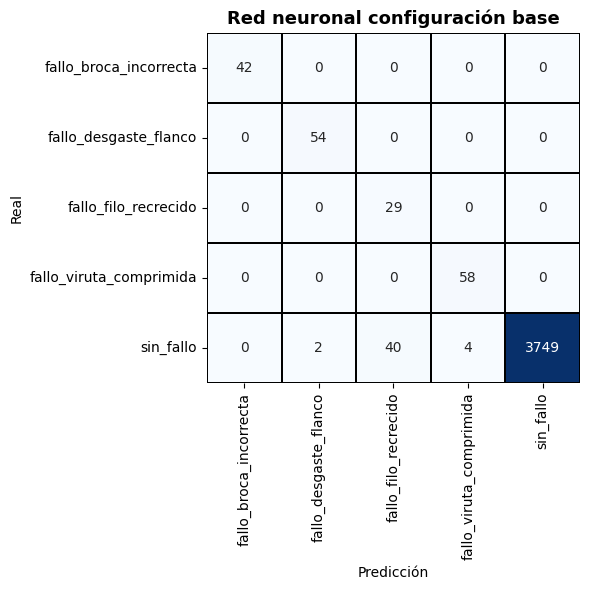

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


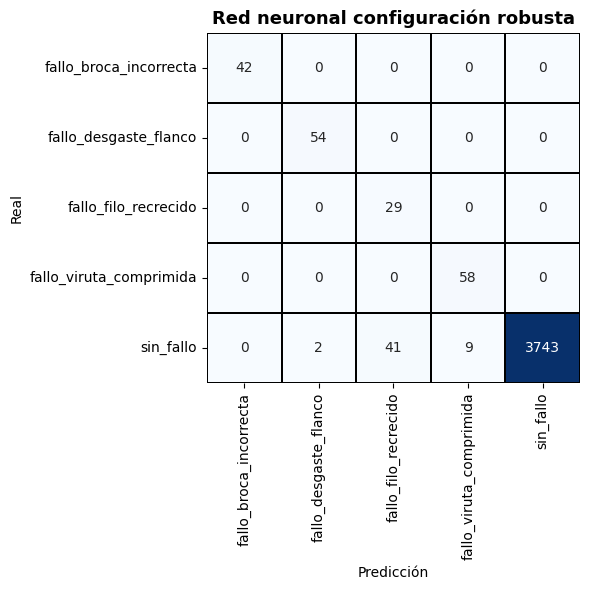

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


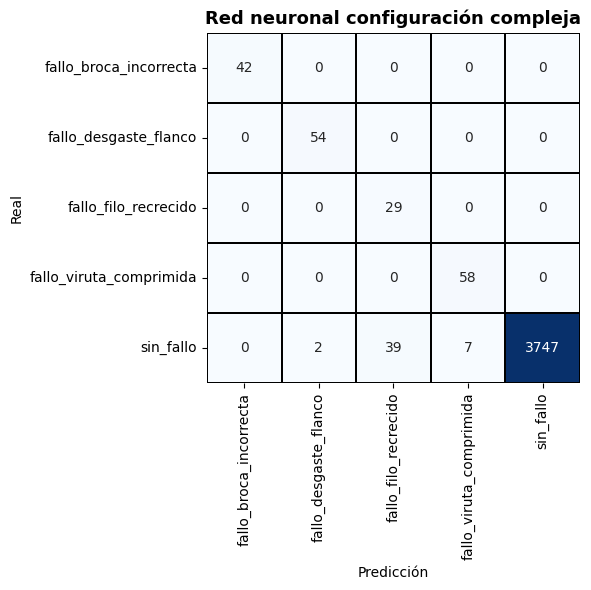

In [72]:
# PASO 4: matrices de confusión
for nombre, modelo in modelos_nn.items():
    y_pred_enc = modelo.predict(X_test_scaled).argmax(axis=1)
    y_pred = le.inverse_transform(y_pred_enc)

    cm = confusion_matrix(y_test, y_pred, labels=le.classes_)

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                cbar=False, linewidths=0.15, linecolor='black')
    ax.set_title(f'Red neuronal configuración {nombre}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    plt.tight_layout()
    plt.show()

In [73]:
# PASO 5: tabla comparativa
resumen_nn = {}

for nombre, modelo in modelos_nn.items():
    y_pred_enc = modelo.predict(X_test_scaled).argmax(axis=1)
    y_pred = le.inverse_transform(y_pred_enc)
    report = classification_report(y_test, y_pred, output_dict=True)
    resumen_nn[nombre] = {
        'accuracy':        report['accuracy'],
        'f1_macro':        report['macro avg']['f1-score'],
        'recall_macro':    report['macro avg']['recall'],
        'precision_macro': report['macro avg']['precision']
    }

df_resumen_nn = pd.DataFrame(resumen_nn).T.round(4)
print("\n" + "="*60)
print("COMPARATIVA ENTRE CONFIGURACIONES — RED NEURONAL")
print("="*60)
print(df_resumen_nn.to_string())

mejor_nn = df_resumen_nn['recall_macro'].idxmax()
print(f"\nMejor configuración: {mejor_nn.upper()}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

COMPARATIVA ENTRE CONFIGURACIONES — RED NEURONAL
          accuracy  f1_macro  recall_macro  precision_macro
base        0.9884    0.9068        0.9976           0.8640
robusta     0.9869    0.8978        0.9973           0.8488
compleja    0.9879    0.9033        0.9975           0.8566

Mejor configuración: BASE


<a id='4_3'></a>
## **4.3 Comparativa de las métricas de los mejores modelos (*Model Comparison*)**

Mejores configuraciones seleccionadas:
  Logistic Regression: base
  Random Forest:       default
  XGBoost:             default
  Red Neuronal MLP:    base

Comparación de los mejores modelos
                     accuracy  f1_macro  recall_macro  precision_macro
Logistic Regression    0.5307    0.5488        0.8263           0.5608
Random Forest          0.9990    0.9913        0.9895           0.9931
XGBoost                0.9975    0.9713        0.9926           0.9533
Red Neuronal           0.9884    0.9068        0.9976           0.8640

Mejor modelo global por recall_macro: Red Neuronal
Mejor modelo global por f1_macro: Random Forest


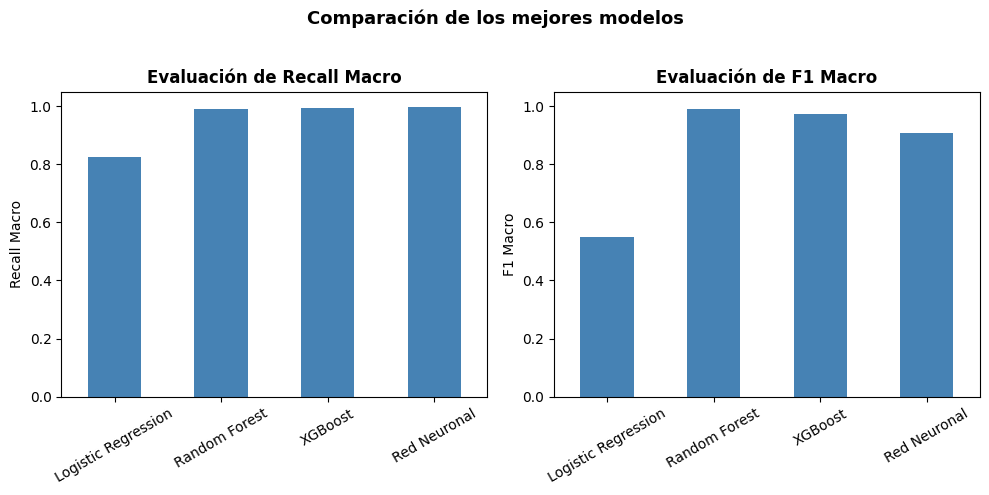

In [74]:
resumen_final = {
    'Logistic Regression': resumen_lr[mejor_lr],
    'Random Forest':       resumen_rf[mejor_rf],
    'XGBoost':             resumen_xgb[mejor_xgb],
    'Red Neuronal':        resumen_nn[mejor_nn]
}
print("Mejores configuraciones seleccionadas:")
print(f"  Logistic Regression: {mejor_lr}")
print(f"  Random Forest:       {mejor_rf}")
print(f"  XGBoost:             {mejor_xgb}")
print(f"  Red Neuronal MLP:    {mejor_nn}")


df_final = pd.DataFrame(resumen_final).T.round(4)
print("\n" + "="*70)
print("Comparación de los mejores modelos")
print("="*70)
print(df_final.to_string())

# Identificar el mejor modelo global
mejor_global = df_final['recall_macro'].idxmax()
print(f"\nMejor modelo global por recall_macro: {mejor_global}")
mejor_global_f1 = df_final['f1_macro'].idxmax()
print(f"Mejor modelo global por f1_macro: {mejor_global_f1}")

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

df_final['recall_macro'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Evaluación de Recall Macro', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Recall Macro')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=30)

df_final['f1_macro'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Evaluación de F1 Macro', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Macro')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Comparación de los mejores modelos\n', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

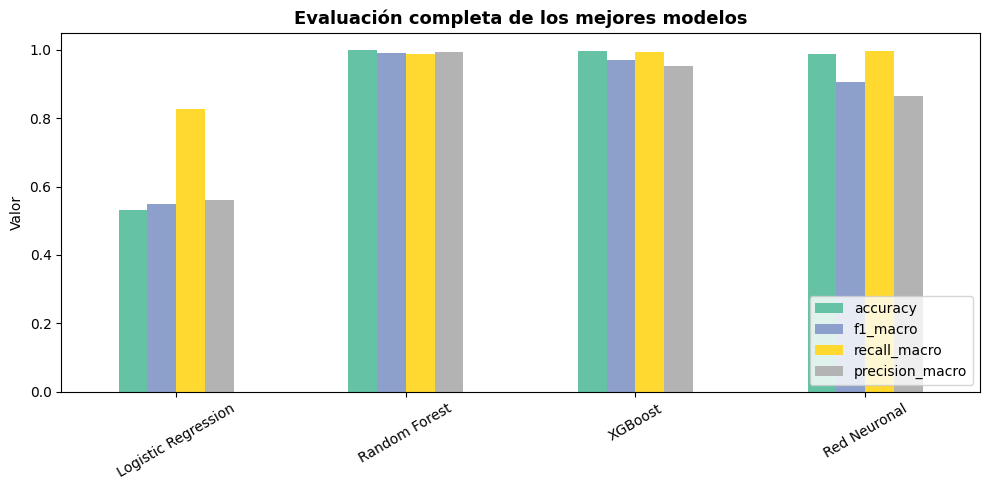

In [75]:
# Gráfica combinada con las 4 métricas
df_final.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Evaluación completa de los mejores modelos', fontsize=13, fontweight='bold')
plt.ylabel('Valor')
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Mejor modelo global: Random Forest.

## **4.4 Comprobación de sobreajuste**

In [76]:
# COMPROBACIÓN DE SOBREAJUSTE
print("="*64)
print("COMPROBACIÓN DE SOBREAJUSTE")
print("="*64)

# REGRESIÓN LOGÍSTICA
print("\n--- REGRESIÓN LOGÍSTICA ---")
mejor_modelo_lr = modelos_lr[mejor_lr]
y_train_pred_lr = mejor_modelo_lr.predict(X_train_bal)
y_test_pred_lr  = mejor_modelo_lr.predict(X_test_scaled)
print(f"Recall macro Train: {recall_score(y_train_bal, y_train_pred_lr, average='macro'):.4f}")
print(f"Recall macro Test:  {recall_score(y_test, y_test_pred_lr, average='macro'):.4f}")

# RANDOM FOREST
print("\n--- RANDOM FOREST ---")
mejor_modelo_rf = modelos_rf[mejor_rf]
mejor_modelo_rf.verbose = 0
y_train_pred_rf = mejor_modelo_rf.predict(X_train_bal)
y_test_pred_rf  = mejor_modelo_rf.predict(X_test_scaled)
print(f"Recall macro Train: {recall_score(y_train_bal, y_train_pred_rf, average='macro'):.4f}")
print(f"Recall macro Test:  {recall_score(y_test, y_test_pred_rf, average='macro'):.4f}")

# XGBOOST
print("\n--- XGBOOST ---")
mejor_modelo_xgb = modelos_xgb[mejor_xgb]
y_train_pred_xgb_enc = mejor_modelo_xgb.predict(X_train_bal)
y_train_pred_xgb     = le.inverse_transform(y_train_pred_xgb_enc)
y_test_pred_xgb_enc  = mejor_modelo_xgb.predict(X_test_scaled)
y_test_pred_xgb      = le.inverse_transform(y_test_pred_xgb_enc)
print(f"Recall macro Train: {recall_score(y_train_bal, y_train_pred_xgb, average='macro'):.4f}")
print(f"Recall macro Test:  {recall_score(y_test, y_test_pred_xgb, average='macro'):.4f}")

# RED NEURONAL MLP
print("\n--- RED NEURONAL MLP ---")
mejor_modelo_nn = modelos_nn[mejor_nn]
y_train_pred_nn_enc = mejor_modelo_nn.predict(X_train_bal).argmax(axis=1)
y_train_pred_nn     = le.inverse_transform(y_train_pred_nn_enc)
y_test_pred_nn_enc  = mejor_modelo_nn.predict(X_test_scaled).argmax(axis=1)
y_test_pred_nn      = le.inverse_transform(y_test_pred_nn_enc)
print(f"Recall macro Train: {recall_score(y_train_bal, y_train_pred_nn, average='macro'):.4f}")
print(f"Recall macro Test:  {recall_score(y_test, y_test_pred_nn, average='macro'):.4f}")

COMPROBACIÓN DE SOBREAJUSTE

--- REGRESIÓN LOGÍSTICA ---
Recall macro Train: 0.8138
Recall macro Test:  0.8263

--- RANDOM FOREST ---
Recall macro Train: 1.0000
Recall macro Test:  0.9895

--- XGBOOST ---
Recall macro Train: 1.0000
Recall macro Test:  0.9926

--- RED NEURONAL MLP ---
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step
Recall macro Train: 0.9977
Recall macro Test:  0.9976


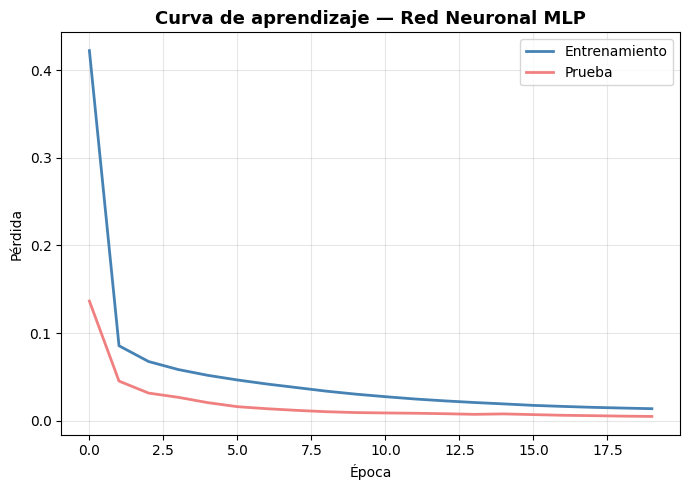

In [77]:
# Curva aprendizaje mejor configuración RED NEURONAL MLP
historial_mejor = historiales[mejor_nn]

plt.figure(figsize=(7, 5))
plt.plot(historial_mejor.history['loss'],
         label='Entrenamiento', color='steelblue', linewidth=2)
plt.plot(historial_mejor.history['val_loss'],
         label='Prueba', color='lightcoral', linewidth=2)

plt.title(f'Curva de aprendizaje — Red Neuronal MLP',
          fontsize=13, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id='5'></a>
# **5. Interpretabilidad y pruebas de los modelos (*XAI & Inference*)**
---

El análisis SHAP se realizó sobre el conjunto de test completo, garantizando la representatividad de todas las clases.

<a id='5_1'></a>
## **5.1 IA explicable: Análisis SHAP (*XAI - SHAP*)**

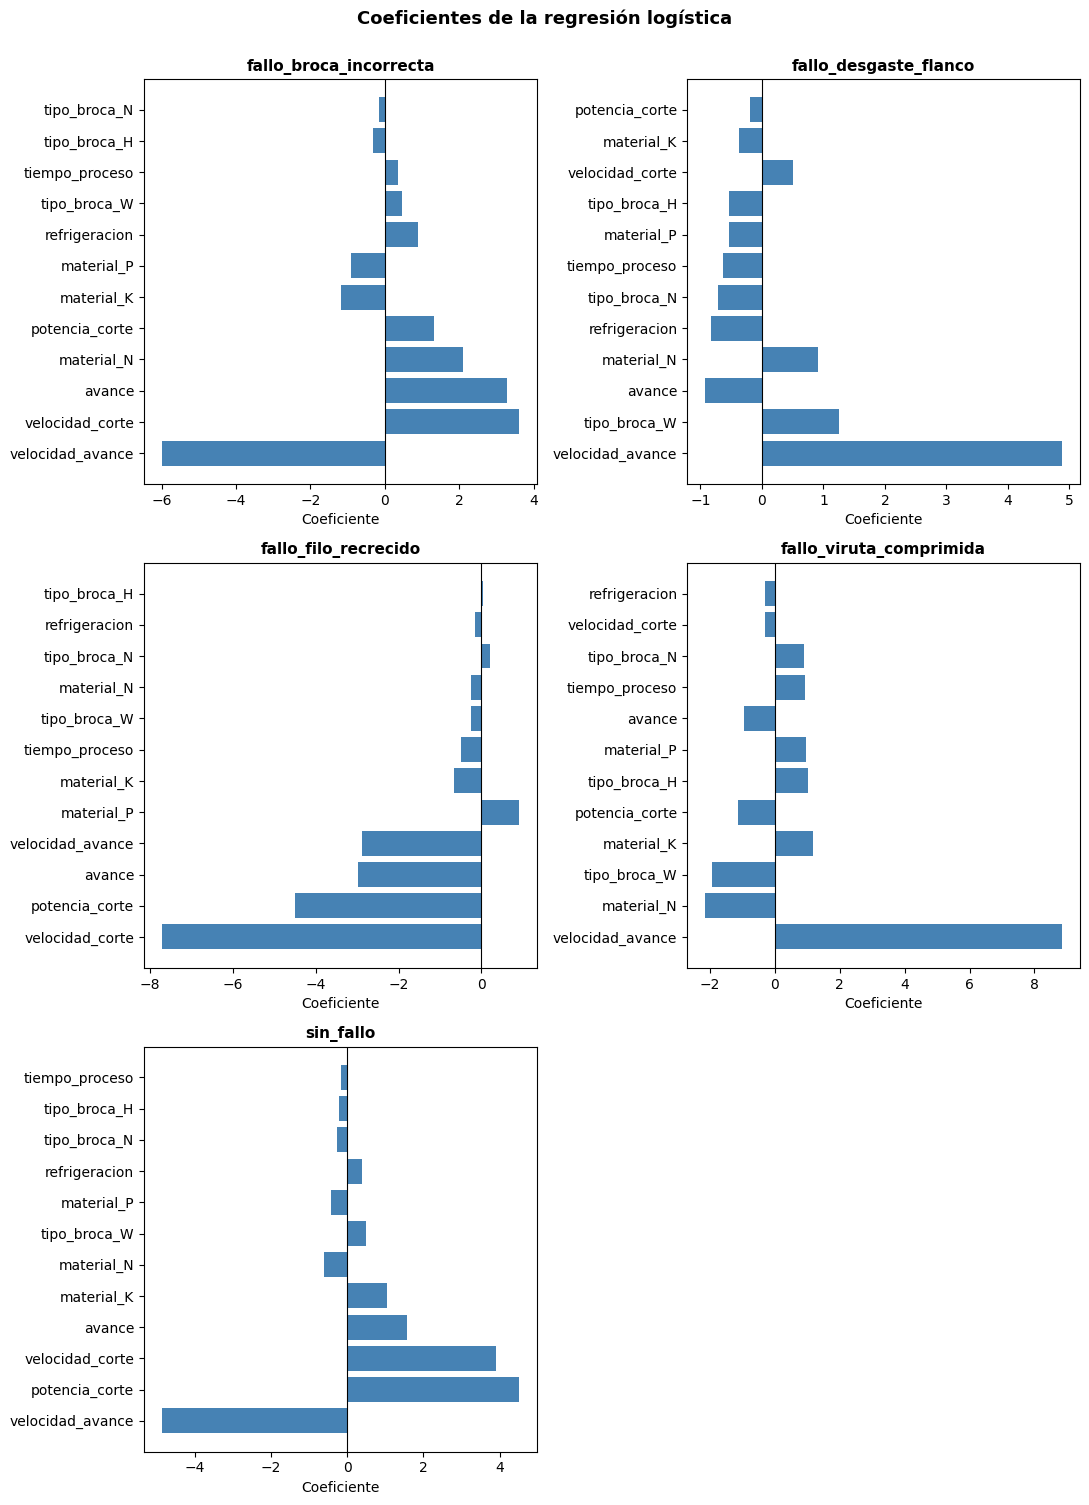

In [78]:
# XAI – COEFICIENTES REGRESIÓN LOGÍSTICA
mejor_modelo_lr = modelos_lr[mejor_lr]
clases = mejor_modelo_lr.classes_
coeficientes = mejor_modelo_lr.coef_
features = X_train.columns

fig, axes = plt.subplots(3, 2, figsize=(11, 15))
axes = axes.flatten()

for i, clase in enumerate(clases):
    coef = coeficientes[i]
    indices = np.argsort(np.abs(coef))[::-1]

    axes[i].barh(range(len(features)), coef[indices], color='steelblue')
    axes[i].set_yticks(range(len(features)))
    axes[i].set_yticklabels(features[indices])
    axes[i].set_title(clase, fontsize=11, fontweight='bold')
    axes[i].axvline(x=0, color='black', linewidth=0.8)
    axes[i].set_xlabel('Coeficiente')

# Eliminar el subplot sobrante (5 clases y 6 subplots)
fig.delaxes(axes[5])

plt.suptitle('Coeficientes de la regresión logística',
             fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

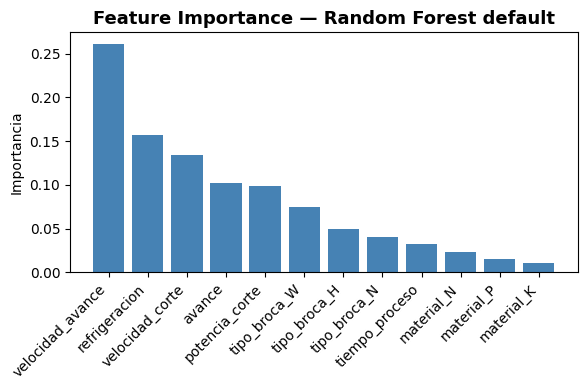

In [79]:
# XAI – FEATURE IMPORTANCE – RANDOM FOREST

mejor_modelo_rf = modelos_rf[mejor_rf]
mejor_modelo_rf.verbose = 0
importances = mejor_modelo_rf.feature_importances_
features = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(6, 4))
plt.bar(range(len(features)), importances[indices], color='steelblue')
plt.xticks(range(len(features)), features[indices], rotation=45, ha='right')
plt.title(f'Feature Importance — Random Forest {mejor_rf}', fontsize=13, fontweight='bold')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

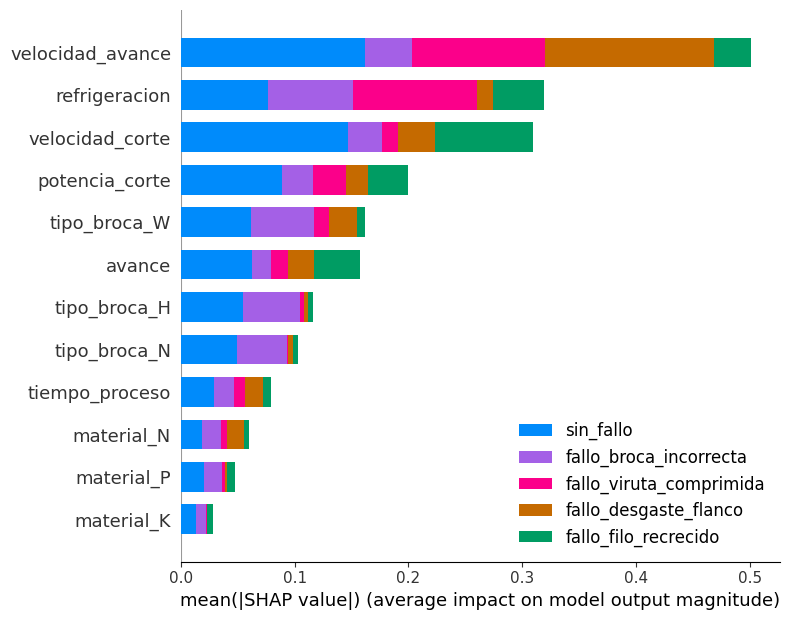

In [80]:
# XAI — SHAP — RANDOM FOREST
mejor_modelo_rf.verbose = 0
explainer = shap.TreeExplainer(mejor_modelo_rf)
shap_values = explainer.shap_values(X_test_scaled)

# Mapear nombres de clases
class_names = modelo_rf_2_robusto.classes_
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=list(X_train.columns),
                  class_names=class_names,
                  plot_type='bar')


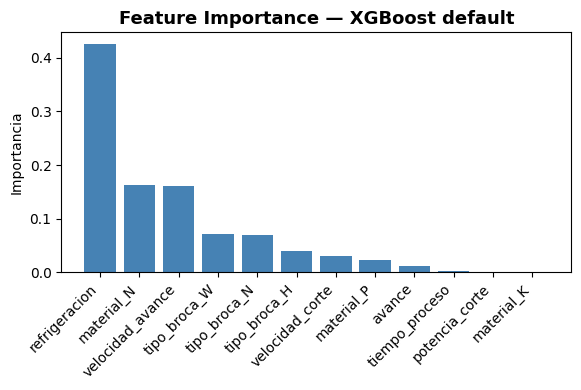

In [81]:
# XAI — FEATURE IMPORTANCE — XGBOOST
modelo_mejor_xgb = modelos_xgb[mejor_xgb]
importances_xgb = modelo_mejor_xgb.feature_importances_
features = X_train.columns
indices = np.argsort(importances_xgb)[::-1]

plt.figure(figsize=(6, 4))
plt.bar(range(len(features)), importances_xgb[indices], color='steelblue')
plt.xticks(range(len(features)), features[indices], rotation=45, ha='right')
plt.title(f'Feature Importance — XGBoost {mejor_xgb}', fontsize=13, fontweight='bold')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

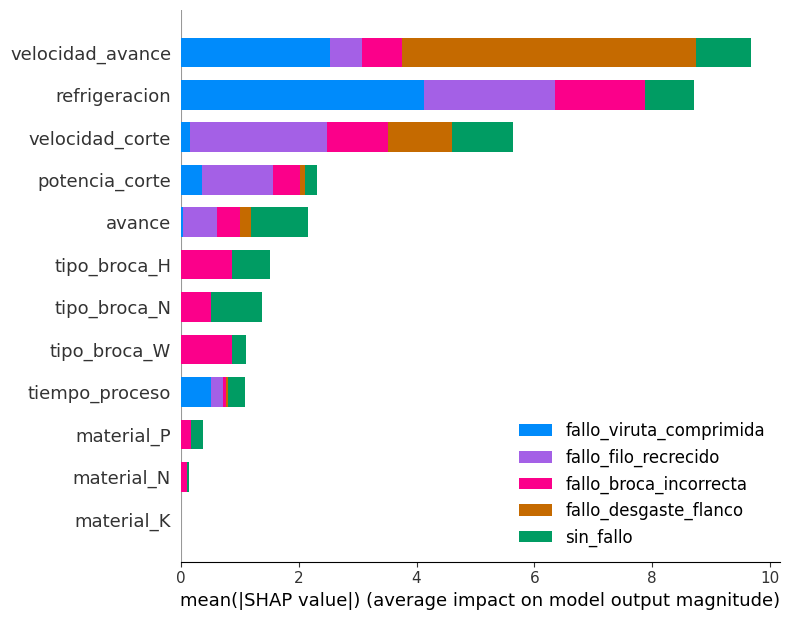

In [82]:
# XAI – SHAP – XGBOOST
explainer_xgb = shap.TreeExplainer(modelos_xgb[mejor_xgb])
shap_values_xgb = explainer_xgb.shap_values(X_test_scaled)

shap.summary_plot(shap_values_xgb, X_test_scaled,
                  feature_names=list(X_train.columns),
                  class_names=le.classes_,
                  plot_type='bar')

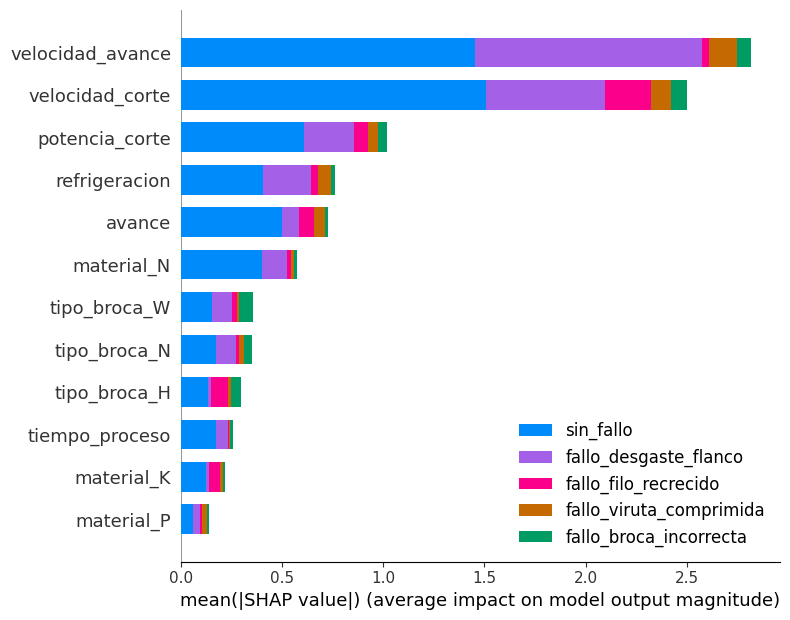

In [83]:
# XAI – SHAP – RED NEURONAL
# Background estratificado y en float32
# DeepExplainer necesita una muestra de background
# Se usan 100 muestras aleatorias del train
background = resample(X_train_bal, n_samples=100,
                      random_state=42,
                      stratify=y_train_bal).astype(np.float32)

# Test en float32
X_test_f32 = X_test_scaled.astype(np.float32)
# Explainer
explainer_nn = shap.DeepExplainer(modelos_nn['compleja'], background)
# SHAP values sobre todo el test
shap_values_nn = explainer_nn.shap_values(X_test_f32)
# Convertir a array 3D correcto
shap_values_array = np.array(shap_values_nn)  # (n_clases, n_samples, n_features)

shap.summary_plot(
    shap_values_array,
    X_test_f32,
    feature_names=list(X_train.columns),
    class_names=list(le.classes_),
    plot_type='bar',
    max_display=15
)

<a id='5_2'></a>
## **5.2 Inferencia para casos individuales (*Prediction for a Single Instance*)**

Para verificar que las predicciones de los modelos son correctas, se va a analizar un caso individual con modelo default de *Random Forest*. Este modelo es el que ha obtenido una valoración global superior a los otros modelos (media de todas las métricas) y algoritmos implementados.

In [84]:
modelos_finales = {
    'Logistic Regression': modelos_lr[mejor_lr],
    'Random Forest':       modelos_rf[mejor_rf],
    'XGBoost':             modelos_xgb[mejor_xgb],
    'Red Neuronal':        modelos_nn[mejor_nn]
}

modelo = modelos_rf[mejor_rf] # Se establece este modelo fijo para no tener problemas con la variabilidad en la reproducibilidad del código (red neuronal)
#modelo = modelos_finales[mejor_global]
joblib.dump(modelo, 'mejor_modelo_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')

# Cargar modelo y scaler
modelo = joblib.load('mejor_modelo_rf.pkl')
scaler = joblib.load('scaler.pkl')
encoder = joblib.load('encoder.pkl')

modelo.verbose = 0

<a id='5_2_1'></a>
### **5.2.1 Inferencia sobre casos reales del test**

Para cada caso individual, el modelo devuelve la clase predicha y la probabilidad asociada a cada modo de fallo.

En el caso del Random Forest, esta probabilidad representa la fracción de árboles del ensemble que votan por cada clase: un valor cercano al 100% indica un alto consenso entre los árboles y por tanto una mayor confianza en la predicción.

In [85]:
clases = ['fallo_filo_recrecido', 'fallo_broca_incorrecta',
          'fallo_desgaste_flanco', 'fallo_viruta_comprimida', 'sin_fallo']

print("="*60)
print("INFERENCIA SOBRE CASOS REALES DEL TEST")
print("="*60)

for clase in clases:
    # Buscar el primer caso de esa clase en y_test
    idx = y_test[y_test == clase].index[0]
    pos = y_test.index.get_loc(idx)

    caso_real = X_test_scaled[pos:pos+1]
    etiqueta_real = y_test.iloc[pos]
    prediccion = modelo.predict(caso_real)[0]
    probs = modelo.predict_proba(caso_real)[0]

    print(f"\nEtiqueta real:  {etiqueta_real}")
    print(f"Predicción:     {prediccion}")
    print(f"¿Correcto?:     {'Sí' if etiqueta_real == prediccion else 'No'}")
    print(f"Probabilidad:   {max(probs):.2%}")
    print("-"*60)

INFERENCIA SOBRE CASOS REALES DEL TEST

Etiqueta real:  fallo_filo_recrecido
Predicción:     fallo_filo_recrecido
¿Correcto?:     Sí
Probabilidad:   100.00%
------------------------------------------------------------

Etiqueta real:  fallo_broca_incorrecta
Predicción:     fallo_broca_incorrecta
¿Correcto?:     Sí
Probabilidad:   100.00%
------------------------------------------------------------

Etiqueta real:  fallo_desgaste_flanco
Predicción:     fallo_desgaste_flanco
¿Correcto?:     Sí
Probabilidad:   100.00%
------------------------------------------------------------

Etiqueta real:  fallo_viruta_comprimida
Predicción:     fallo_viruta_comprimida
¿Correcto?:     Sí
Probabilidad:   100.00%
------------------------------------------------------------

Etiqueta real:  sin_fallo
Predicción:     sin_fallo
¿Correcto?:     Sí
Probabilidad:   100.00%
------------------------------------------------------------


<a id='5_2_2'></a>
### **5.2.2 Inferencia sobre casos hipotéticos**

Los casos de desgaste de flanco, viruta comprimida y broca incorrecta presentan probabilidades más bajas (50-61%) debido a que estos modos de fallo dependen de la combinación de múltiples condiciones simultáneas (paper original). Los parámetros empleados se encuentran en zona límite. Esta situación refleja la dificultad real de detectar este tipo de fallos en condiciones frontera.

In [86]:
# CASO 1: Sin fallo
caso_sin_fallo = {
    'velocidad_corte':   22.5,
    'avance':            0.18,
    'velocidad_avance':  110.0,
    'potencia_corte':    85.0,
    'refrigeracion':     25,
    'tiempo_proceso':    34.0,
    'material_K':        0,
    'material_N':        0,
    'material_P':        1,
    'tipo_broca_H':      0,
    'tipo_broca_N':      1,
    'tipo_broca_W':      0
}

# CASO 2: Filo recrecido
# Material P (acero), velocidad baja, refrigeración 0%
caso_recrecido = {
    'velocidad_corte':   17.0,
    'avance':            0.13,
    'velocidad_avance':  80.0,
    'potencia_corte':    60.0,
    'refrigeracion':     0,
    'tiempo_proceso':    36.0,
    'material_K':        0,
    'material_N':        0,
    'material_P':        1,
    'tipo_broca_H':      0,
    'tipo_broca_N':      1,
    'tipo_broca_W':      0
}

# CASO 3: Desgaste de flanco
# Material N (aluminio), velocidad alta, avance alto
caso_desgaste = {
    'velocidad_corte':   30.0,
    'avance':            0.24,
    'velocidad_avance':  220.0,
    'potencia_corte':    210.0,
    'refrigeracion':     75,
    'tiempo_proceso':    19.0,
    'material_K':        0,
    'material_N':        1,
    'material_P':        0,
    'tipo_broca_H':      0,
    'tipo_broca_N':      0,
    'tipo_broca_W':      1
}

# CASO 4: Broca incorrecta
# Material N (aluminio) con broca N (incorrecta para aluminio)
caso_broca = {
    'velocidad_corte':   30.0,
    'avance':            0.24,
    'velocidad_avance':  220.0,
    'potencia_corte':    210.0,
    'refrigeracion':     50,
    'tiempo_proceso':    19.0,
    'material_K':        0,
    'material_N':        1,
    'material_P':        0,
    'tipo_broca_H':      0,
    'tipo_broca_N':      1,
    'tipo_broca_W':      0
}

# CASO 5: Viruta comprimida
# Material P (acero), avance alto, refrigeración baja
caso_viruta = {
    'velocidad_corte':   17.5,
    'avance':            0.24,
    'velocidad_avance':  130.0,
    'potencia_corte':    75.0,
    'refrigeracion':     25,
    'tiempo_proceso':    32.0,
    'material_K':        0,
    'material_N':        0,
    'material_P':        1,
    'tipo_broca_H':      0,
    'tipo_broca_N':      1,
    'tipo_broca_W':      0
}

# Predecir los 5 casos
for nombre, caso in [('Sin fallo',        caso_sin_fallo),
                     ('Filo recrecido',  caso_recrecido),
                     ('Desgaste flanco',   caso_desgaste),
                     ('Broca incorrecta',  caso_broca),
                     ('Viruta comprimida', caso_viruta)]:
    df = pd.DataFrame([caso])
    scaled = scaler.transform(df)
    pred = modelo.predict(scaled)[0]
    probs = modelo.predict_proba(scaled)[0]
    print(f"\nCaso esperado:             {nombre}")
    print(f"Modo de fallo predicho:    {pred}")
    print("Probabilidades:")
    for clase, prob in zip(modelo.classes_, probs):
        print(f"  {clase:30s} {prob:.2%}")
    print("-"*50)


Caso esperado:             Sin fallo
Modo de fallo predicho:    sin_fallo
Probabilidades:
  fallo_broca_incorrecta         0.00%
  fallo_desgaste_flanco          0.00%
  fallo_filo_recrecido           1.00%
  fallo_viruta_comprimida        2.00%
  sin_fallo                      97.00%
--------------------------------------------------

Caso esperado:             Filo recrecido
Modo de fallo predicho:    fallo_filo_recrecido
Probabilidades:
  fallo_broca_incorrecta         0.00%
  fallo_desgaste_flanco          0.00%
  fallo_filo_recrecido           97.00%
  fallo_viruta_comprimida        0.00%
  sin_fallo                      3.00%
--------------------------------------------------

Caso esperado:             Desgaste flanco
Modo de fallo predicho:    fallo_desgaste_flanco
Probabilidades:
  fallo_broca_incorrecta         0.00%
  fallo_desgaste_flanco          51.00%
  fallo_filo_recrecido           0.00%
  fallo_viruta_comprimida        0.00%
  sin_fallo                      49.00%
--

<a id='6'></a>
# **6. Diseño de la aplicación e interfaz (*Building the Application*)**
---

In [87]:
def predecir_fallo(velocidad_corte, avance, velocidad_avance,
                   potencia_corte, refrigeracion, tiempo_proceso,
                   material, tipo_broca):

    # Codificar con encoder
    categoricas = encoder.transform([[material, tipo_broca]])
    numericas = [[velocidad_corte, avance, velocidad_avance,
                  potencia_corte, refrigeracion, tiempo_proceso]]
    caso = np.hstack([numericas, categoricas])
    caso_df = pd.DataFrame(caso, columns=list(X.columns))

    # Escalar y predecir
    caso_scaled = scaler.transform(caso_df)
    prediccion = modelo.predict(caso_scaled)[0]
    probabilidades = modelo.predict_proba(caso_scaled)[0]

    nombres = {
        'fallo_filo_recrecido':    'Filo recrecido',
        'fallo_broca_incorrecta':  'Broca incorrecta',
        'fallo_desgaste_flanco':   'Desgaste de flanco',
        'fallo_viruta_comprimida': 'Viruta comprimida',
        'sin_fallo':               'Sin fallo'
    }

    resultado = f"Fallo detectado: {nombres[prediccion]}\n\n"
    resultado += "Probabilidad para cada modo de fallo:\n"
    for clase, prob in zip(modelo.classes_, probabilidades):
        resultado += f"- {nombres[clase]}: {prob:.2%}\n"

    return resultado

demo = gr.Interface(
    fn=predecir_fallo,
    inputs=[
        gr.Slider(minimum=16.33, maximum=31.07, value=17.5, label="Velocidad de corte (m/min)"),
        gr.Slider(minimum=0.108, maximum=0.321, value=0.24, step=0.001, label="Avance (mm/rev)"),
        gr.Slider(minimum=62, maximum=261, value=130, label="Velocidad de avance (mm/min)"),
        gr.Slider(minimum=49.04, maximum=310, value=75, label="Potencia de corte (kW)"),
        gr.Dropdown(choices=[0, 25, 50, 75, 100], value=25, label="Refrigeración (%)"),
        gr.Slider(minimum=15.97, maximum=38.57, value=32.0, label="Tiempo de proceso (s)"),
        gr.Dropdown(choices=['P', 'K', 'N'], value='P', label="Material"),
        gr.Dropdown(choices=['N', 'H', 'W'], value='N', label="Tipo de broca")
    ],
    outputs=gr.Textbox(label="Predicción"),
    title="Detección de los modos de fallo en una taladradora",
    description="Introduzca los parámetros de la operación de taladrado para predecir el modo de fallo.<br><b>Nota:</b> los parámetros de proceso están relacionados matemáticamente. Introduzca valores coherentes con las relaciones vf = f · n y Pc = F · vc/1000.",
    theme=gr.themes.Soft(),
    submit_btn="Predecir",
    clear_btn="Limpiar",
    flagging_mode="never"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7b50aea84dd2bff7c2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
